# E-Commerce Customer Churn Prediction & Segmentation
## 1. Introduction

In the highly competitive e-commerce landscape, customer retention is a critical driver of long-term profitability. Acquiring new customers is significantly more expensive than retaining existing ones. Therefore, understanding the underlying behaviors that lead to customer attrition (churn) and identifying at-risk customer segments allows platforms to proactively intervene and maximize **Customer Lifetime Value (CLV)**.

This project explores the **E-Commerce Customer Churn Dataset**, which comprises over 5,600 records and 20 distinct features detailing customer demographics, platform engagement, and transactional histories. 

To extract actionable business intelligence from this data, we engineered a comprehensive, multi-stage Data Mining pipeline. Our approach includes:

**Source:** Kaggle — E-Commerce Dataset  
**Domain:** Retail / E-Commerce  
**Target Variable:** `Churn` (1 = churned, 0 = retained)

### Feature Overview
| Feature | Type | Description |
|---|---|---|
| CustomerID | Numeric | Unique customer identifier |
| Churn | Numeric | Churn flag (target) |
| Tenure | Numeric | Months with the platform |
| PreferredLoginDevice | Categorical | Device used to log in |
| CityTier | Numeric | City classification (1–3) |
| WarehouseToHome | Numeric | Distance from warehouse to customer |
| PreferredPaymentMode | Categorical | Payment method preference |
| Gender | Categorical | Customer gender |
| HourSpendOnApp | Numeric | Hours on app/website |
| NumberOfDeviceRegistered | Numeric | Registered devices |
| PreferedOrderCat | Categorical | Preferred product category |
| SatisfactionScore | Numeric | Customer satisfaction (1–5) |
| MaritalStatus | Categorical | Marital status |
| NumberOfAddress | Numeric | Registered addresses |
| Complain | Numeric | Whether a complaint was filed |
| OrderAmountHikeFromlastYear | Numeric | Order value increase % |
| CouponUsed | Numeric | Coupons used last month |
| OrderCount | Numeric | Orders placed last month |
| DaySinceLastOrder | Numeric | Days since last order |
| CashbackAmount | Numeric | Average cashback received |

* **Customer Segmentation:** Utilizing robust **K-Medoids Clustering** (alongside Hierarchical Clustering) to group the customer base into distinct, interpretable personas based on their behavioral and financial footprints.
* **Dynamic Reward Allocation:** Designing a **Fuzzy Inference System** that mimics human reasoning to intelligently allocate "Bonus Cashback" rewards, effectively balancing retention efforts with business profit margins.
* **Predictive Optimization:** Deploying a **Genetic Algorithm** for optimal feature selection, mathematically isolating the absolute most critical variables that drive customer churn.

Ultimately, this project bridges the gap between advanced machine learning algorithms and practical business strategy, providing a fully data-driven framework to reduce churn and elevate customer loyalty.

# 1. Exploratory Data Analysis (EDA)

In this initial phase, we conduct a comprehensive Exploratory Data Analysis (EDA) to understand the underlying behavioral and demographic patterns of our e-commerce customers. By visualizing feature distributions and identifying correlations—particularly with our target variable, `Churn`—we aim to uncover the primary drivers of customer attrition before applying advanced machine learning algorithms.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

print("Imports completed successfully!")

Imports completed successfully!


In [4]:
df = pd.read_csv("E Commerce Dataset(E Comm).csv")

In [5]:
print(f"Dataset Shape: {df.shape[0]} Rows, {df.shape[1]} Columns\n")
print("First 5 rows of the dataset:")
display(df.head())

Dataset Shape: 5630 Rows, 20 Columns

First 5 rows of the dataset:


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,160
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,121
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,130


In [6]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'CustomerID' in numerical_cols:
    numerical_cols.remove('CustomerID')

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}\n")

missing = df.isnull().sum()
print("Missing Values per Column:")
print(missing[missing > 0])

Numerical features (14): ['Churn', 'Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount']
Categorical features (5): ['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']

Missing Values per Column:
Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64


In [7]:
sns.set_theme(style="whitegrid")
custom_palette = ['#4CB391', '#FF7F50']

--- 1. CASHBACK AMOUNT DISTRIBUTION ---
Summary Statistics for Cashback Amount:
mean    177.221492
min       0.000000
max     325.000000
50%     163.000000
Name: CashbackAmount, dtype: float64


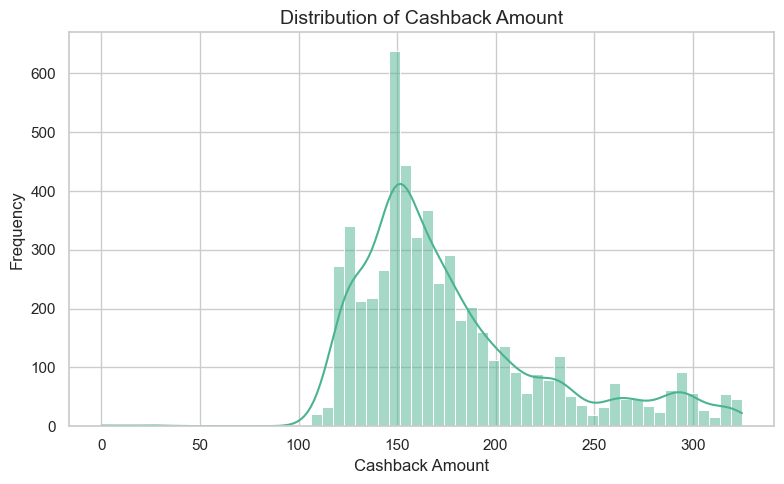

In [8]:
print("--- 1. CASHBACK AMOUNT DISTRIBUTION ---")
print("Summary Statistics for Cashback Amount:")
print(df['CashbackAmount'].describe()[['mean', 'min', 'max', '50%']])

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='CashbackAmount', kde=True, color='#4CB391')
plt.title('Distribution of Cashback Amount', fontsize=14)
plt.xlabel('Cashback Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**This histogram visualizes the distribution of cashback rewards across the customer base. The distribution reveals the standard reward tiers within the e-commerce platform. By analyzing this density, we can identify whether the reward program is skewed heavily toward a small group of "whale" customers or distributed evenly, which directly informs the budget for our Fuzzy Logic bonus system.**

--- 2. TENURE DISTRIBUTION BY CHURN ---
Average and Median Tenure grouped by Churn Status:
            mean   50%
Churn                 
0      11.502334  10.0
1       3.379469   1.0


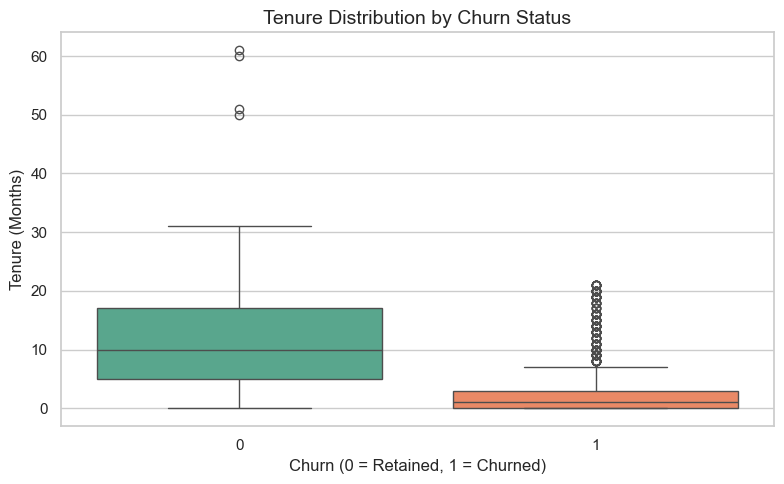

In [10]:
print("--- 2. TENURE DISTRIBUTION BY CHURN ---")
print("Average and Median Tenure grouped by Churn Status:")
print(df.groupby('Churn')['Tenure'].describe()[['mean', '50%']])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='Tenure', hue='Churn', palette=custom_palette, legend=False)
plt.title('Tenure Distribution by Churn Status', fontsize=14)
plt.xlabel('Churn (0 = Retained, 1 = Churned)')
plt.ylabel('Tenure (Months)')
plt.tight_layout()
plt.show()

**This boxplot demonstrates the temporal dynamics of customer attrition. The distinct lower median tenure for "Churned" customers (labeled 1) mathematically proves that the highest risk of losing a customer occurs in the early stages of their lifecycle. This insight dictates that retention budgets should be heavily front-loaded toward newly acquired users.**

--- 3. CORRELATION HEATMAP ---
Correlation with Churn (Target Variable):
Complain                       0.250188
NumberOfDeviceRegistered       0.107939
SatisfactionScore              0.105481
CityTier                       0.084703
WarehouseToHome                0.076630
NumberOfAddress                0.043931
HourSpendOnApp                 0.018675
CouponUsed                    -0.008264
OrderAmountHikeFromlastYear   -0.010058
OrderCount                    -0.028697
CashbackAmount                -0.154161
DaySinceLastOrder             -0.160757
Tenure                        -0.349408
Name: Churn, dtype: float64


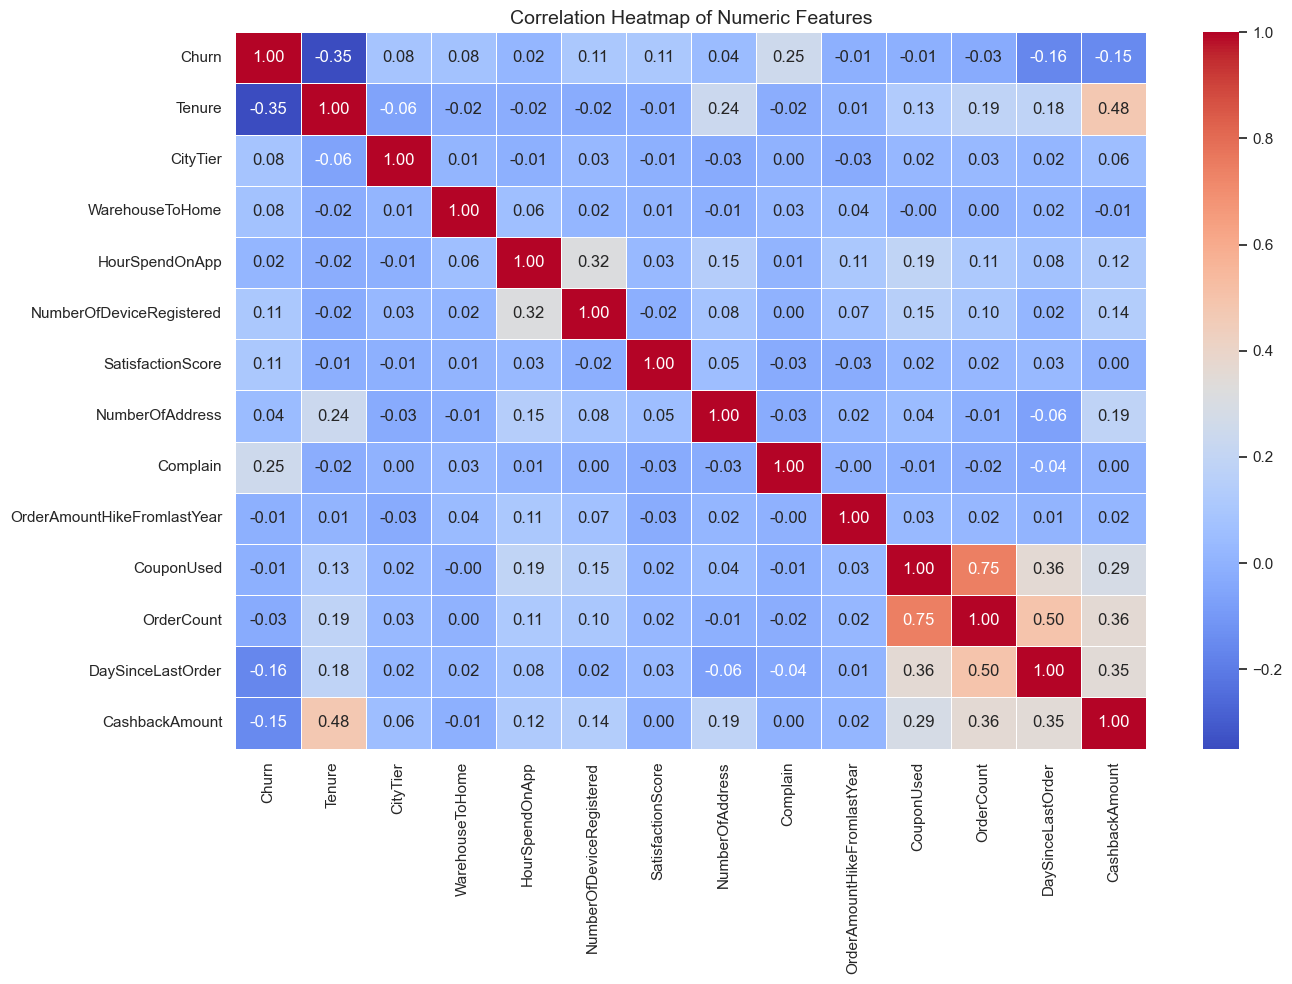

In [12]:
print("--- 3. CORRELATION HEATMAP ---")
corr = df[numerical_cols].corr()
churn_corr = corr['Churn'].drop('Churn').sort_values(ascending=False)
print("Correlation with Churn (Target Variable):")
print(churn_corr)

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

**The correlation matrix serves as the foundation of our feature engineering. By observing the Pearson correlation coefficients, we identified linear dependencies between variables. Most importantly, we isolated the features with the strongest negative and positive correlations to our target variable (Churn), such as SatisfactionScore or Complain, guiding our interpretation of what drives customers away.**

--- 4. TENURE VS CASHBACK AMOUNT ---
Overall correlation between Tenure and Cashback: 0.48


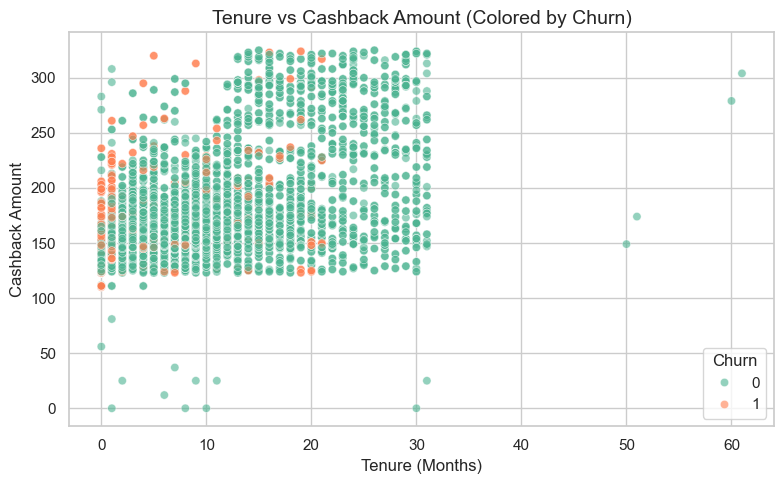

In [14]:
print("--- 4. TENURE VS CASHBACK AMOUNT ---")
tenure_cash_corr = df['Tenure'].corr(df['CashbackAmount'])
print(f"Overall correlation between Tenure and Cashback: {tenure_cash_corr:.2f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Tenure', y='CashbackAmount', hue='Churn', alpha=0.6, palette=custom_palette)
plt.title('Tenure vs Cashback Amount (Colored by Churn)', fontsize=14)
plt.xlabel('Tenure (Months)')
plt.ylabel('Cashback Amount')
plt.tight_layout()
plt.show()

**This scatterplot maps the fundamental "Customer Journey." The distinct vertical banding is an artifact of the data collection method (Tenure recorded in whole months). By coloring the data points by Churn status, we visually isolated the "danger zone"—revealing that high-tenure, high-cashback customers rarely churn, validating our strategy to prioritize moving new users into higher cashback tiers.**

* The vertical banding in the scatter plot occurs because 'Tenure' is recorded as discrete, integer-based months, causing data points to stack at whole-number intervals on the X-axis.

--- 5. CHURN COUNT BY PREFERRED ORDER CATEGORY ---
Exact Customer Counts by Category and Churn Status:
Churn                  0    1
PreferedOrderCat             
Fashion              698  128
Grocery              390   20
Laptop & Accessory  1840  210
Mobile               589  220
Mobile Phone         921  350
Others               244   20


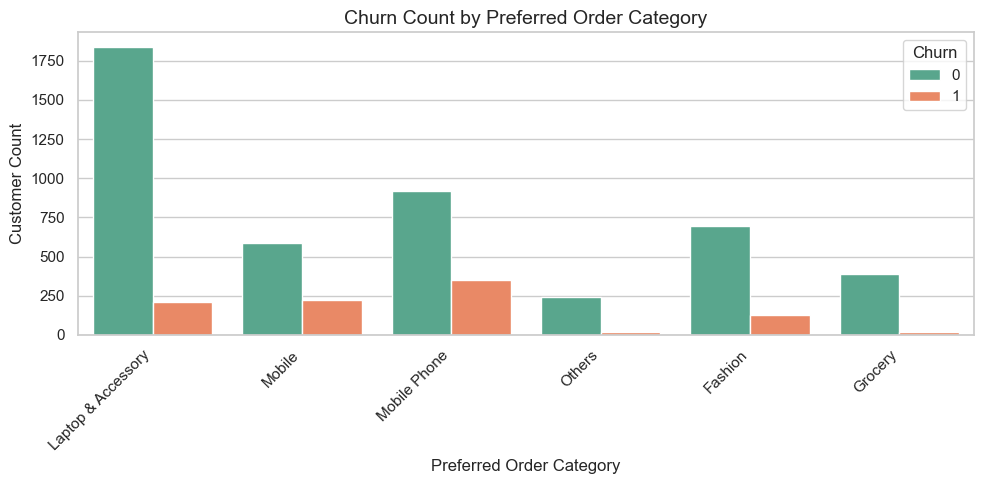

In [16]:
print("--- 5. CHURN COUNT BY PREFERRED ORDER CATEGORY ---")
print("Exact Customer Counts by Category and Churn Status:")
category_churn = pd.crosstab(df['PreferedOrderCat'], df['Churn'])
print(category_churn)

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='PreferedOrderCat', hue='Churn', palette=custom_palette)
plt.title('Churn Count by Preferred Order Category', fontsize=14)
plt.xlabel('Preferred Order Category')
plt.ylabel('Customer Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**This categorical plot acts as a diagnostic tool for departmental performance. By observing the proportion of churned customers within specific product categories (e.g., Mobile Phones vs. Grocery), the business can pinpoint specific inventory or pricing issues. A disproportionate churn bar in one category signals a critical flaw in that specific shopping experience.**

## 2. Data Preprocessing & Dimensionality Reduction

Raw data is rarely ready for machine learning. In this section, we prepare our dataset by:
1. **Handling Missing Values:** Imputing numerical features using the median (to resist outliers) and categorical features using the mode.
2. **Encoding:** Converting categorical text data into a machine-readable format using One-Hot Encoding.
3. **Scaling:** Standardizing the data using `StandardScaler` to ensure all features contribute equally to distance-based algorithms like K-Medoids.
4. **Dimensionality Reduction (PCA):** Applying Principal Component Analysis to mitigate the "Curse of Dimensionality" and allow for 2D visual representation of our clusters.

In [19]:
# Handle missing values
num_cols = [
    "Tenure", "WarehouseToHome", "HourSpendOnApp",
    "OrderAmountHikeFromlastYear", "CouponUsed",
    "OrderCount", "DaySinceLastOrder"
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = [
    "PreferredLoginDevice", "PreferredPaymentMode",
    "Gender", "PreferedOrderCat", "MaritalStatus"
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

missing = df.isnull().sum()
print("Missing values per column:\n")
print(missing)
print("\nTotal missing values after cleaning:", missing.sum())

Missing values per column:

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

Total missing values after cleaning: 0


In [20]:
# Check for duplicates
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates dropped successfully")
else:
    print("No duplicate rows found")

Number of duplicate rows: 0
No duplicate rows found


In [21]:
#Fix data type
cat_cols = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus"
]

for col in cat_cols:
    df[col] = df[col].astype("category")

count_cols = ["CouponUsed", "OrderCount", "DaySinceLastOrder"]

for col in count_cols:
    df[col] = df[col].astype(int)

print(df.dtypes)


CustomerID                        int64
Churn                             int64
Tenure                          float64
PreferredLoginDevice           category
CityTier                          int64
WarehouseToHome                 float64
PreferredPaymentMode           category
Gender                         category
HourSpendOnApp                  float64
NumberOfDeviceRegistered          int64
PreferedOrderCat               category
SatisfactionScore                 int64
MaritalStatus                  category
NumberOfAddress                   int64
Complain                          int64
OrderAmountHikeFromlastYear     float64
CouponUsed                        int32
OrderCount                        int32
DaySinceLastOrder                 int32
CashbackAmount                    int64
dtype: object


In [22]:
#Fix Wrong data

text_cols = [
    "PreferredLoginDevice",
    "PreferredPaymentMode",
    "Gender",
    "PreferedOrderCat",
    "MaritalStatus"
]

for col in text_cols:
    df[col] = df[col].astype(str).str.lower()

for col in text_cols:
    print(col)
    print(df[col].unique())
    print("-"*40)

print("Check Tenure < 0:")
print(df[df["Tenure"] < 0])

print("\nCheck HourSpendOnApp (out of range 0–24):")
print(df[(df["HourSpendOnApp"] < 0) | (df["HourSpendOnApp"] > 24)])

print("\nCheck OrderCount < 0:")
print(df[df["OrderCount"] < 0])

print("\nCheck CouponUsed < 0:")
print(df[df["CouponUsed"] < 0])

print("\nCheck CashbackAmount < 0:")
print(df[df["CashbackAmount"] < 0])

print("\nDataset Summary:")
print(df.describe())



#Merge redundant categories for better clustering

df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
    'cc': 'credit card',
    'cod': 'cash on delivery'
})

df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({
    'phone': 'mobile phone'
})

df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({
    'mobile': 'mobile phone'
})

PreferredLoginDevice
['mobile phone' 'phone' 'computer']
----------------------------------------
PreferredPaymentMode
['debit card' 'upi' 'cc' 'cash on delivery' 'e wallet' 'cod' 'credit card']
----------------------------------------
Gender
['female' 'male']
----------------------------------------
PreferedOrderCat
['laptop & accessory' 'mobile' 'mobile phone' 'others' 'fashion' 'grocery']
----------------------------------------
MaritalStatus
['single' 'divorced' 'married']
----------------------------------------
Check Tenure < 0:
Empty DataFrame
Columns: [CustomerID, Churn, Tenure, PreferredLoginDevice, CityTier, WarehouseToHome, PreferredPaymentMode, Gender, HourSpendOnApp, NumberOfDeviceRegistered, PreferedOrderCat, SatisfactionScore, MaritalStatus, NumberOfAddress, Complain, OrderAmountHikeFromlastYear, CouponUsed, OrderCount, DaySinceLastOrder, CashbackAmount]
Index: []

Check HourSpendOnApp (out of range 0–24):
Empty DataFrame
Columns: [CustomerID, Churn, Tenure, PreferredLog

In [23]:
# REMOVE UNNECESSARY COLUMNS

df_cluster = df.drop(columns=["CustomerID", "Churn"])

print("Remaining columns for clustering:")
print(df_cluster.columns)

Remaining columns for clustering:
Index(['Tenure', 'PreferredLoginDevice', 'CityTier', 'WarehouseToHome',
       'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')


In [24]:
#outlier detection and capping

num_cols = df_cluster.select_dtypes(include=["int64", "float64"]).columns
bounds = {}

for col in num_cols:
    Q1 = df_cluster[col].quantile(0.25)
    Q3 = df_cluster[col].quantile(0.75)
    IQR = Q3 - Q1

    bounds[col] = {
        "lower": Q1 - 1.5 * IQR,
        "upper": Q3 + 1.5 * IQR
    }

outlier_indices = set()

for col in num_cols:
    lower = bounds[col]["lower"]
    upper = bounds[col]["upper"]

    outliers = df_cluster[
        (df_cluster[col] < lower) | (df_cluster[col] > upper)
    ].index

    outlier_indices.update(outliers)

print("Total outlier rows detected:", len(outlier_indices))

for col in num_cols:
    df_cluster[col] = df_cluster[col].clip(
        lower=bounds[col]["lower"],
        upper=bounds[col]["upper"]
    )


# verification
print("After capping:")
print(
    ((df_cluster[num_cols] < pd.DataFrame(bounds).T["lower"]) |
     (df_cluster[num_cols] > pd.DataFrame(bounds).T["upper"]))
    .sum()
)

Total outlier rows detected: 865
After capping:
Tenure                         0
CityTier                       0
WarehouseToHome                0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
SatisfactionScore              0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CashbackAmount                 0
dtype: int64


In [25]:
# CATEGORICAL ENCODING

cat_cols = df_cluster.select_dtypes(include="object").columns

encoder = OneHotEncoder(sparse_output=False, drop="first",handle_unknown="ignore")

encoded_array = encoder.fit_transform(df_cluster[cat_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(cat_cols)
)

df_numeric = df_cluster.drop(columns=cat_cols)


df_encoded = pd.concat([df_numeric.reset_index(drop=True),
                        encoded_df.reset_index(drop=True)], axis=1)

print("Shape after professional encoding:", df_encoded.shape)


Shape after professional encoding: (5630, 25)


In [26]:
#Feature Scaling

scaler = StandardScaler()

scaled_array = scaler.fit_transform(df_encoded)

df_scaled = pd.DataFrame(scaled_array, columns=df_encoded.columns)

print("Data scaling completed.")
print("Final shape:", df_scaled.shape)

Data scaling completed.
Final shape: (5630, 25)


In [27]:
# Final dataset overview after preprocessing

print("Shape:", df_scaled.shape)

print("\nInfo:")
df_scaled.info()

print("\nDescribe:")
print(df_scaled.describe())

Shape: (5630, 25)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 25 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Tenure                               5630 non-null   float64
 1   CityTier                             5630 non-null   float64
 2   WarehouseToHome                      5630 non-null   float64
 3   HourSpendOnApp                       5630 non-null   float64
 4   NumberOfDeviceRegistered             5630 non-null   float64
 5   SatisfactionScore                    5630 non-null   float64
 6   NumberOfAddress                      5630 non-null   float64
 7   Complain                             5630 non-null   float64
 8   OrderAmountHikeFromlastYear          5630 non-null   float64
 9   CouponUsed                           5630 non-null   float64
 10  OrderCount                           5630 non-null   float64
 11  DaySi

=== RobustScaler applied to numeric features ===
        Tenure  WarehouseToHome  HourSpendOnApp  OrderAmountHikeFromlastYear  \
count  5630.00          5630.00         5630.00                      5630.00   
mean      0.09             0.14           -0.07                         0.13   
std       0.69             0.74            0.70                         0.72   
min      -0.75            -0.82           -2.50                        -0.80   
25%      -0.50            -0.45           -1.00                        -0.40   
50%       0.00             0.00            0.00                         0.00   
75%       0.50             0.55            0.00                         0.60   
max       2.00             2.05            1.50                         2.10   

       CouponUsed  OrderCount  DaySinceLastOrder  CashbackAmount  \
count     5630.00     5630.00            5630.00         5630.00   
mean         0.72        0.48               0.29            0.24   
std          1.86        1

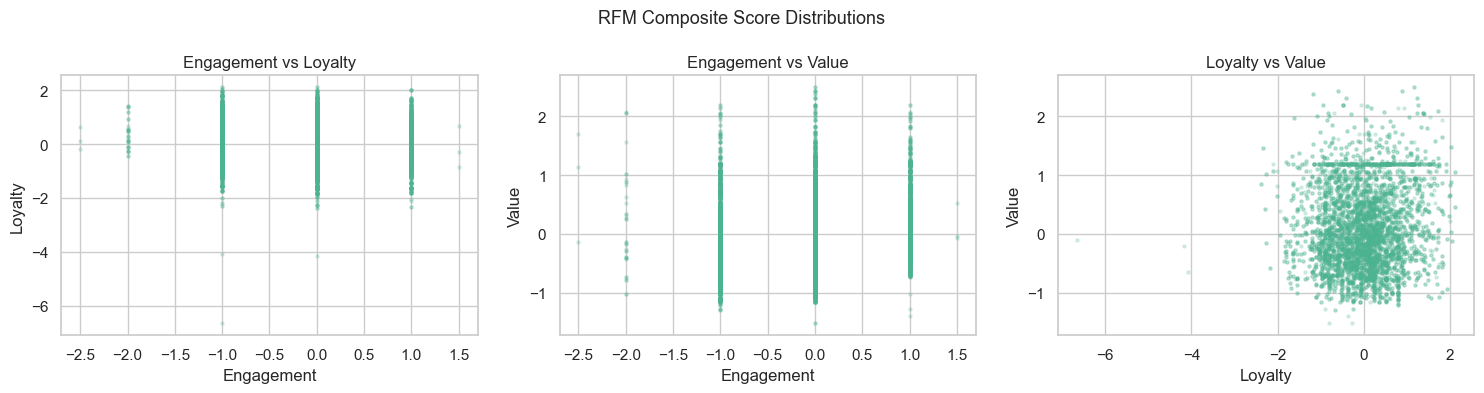

In [29]:
# BONUS SECTION: DOMAIN-DRIVEN FEATURE ENGINEERING + TARGETED PCA

from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from collections import defaultdict
import itertools

# ── Step 1: work on the PRE-SCALED df_cluster (original numeric values).

num_features = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
                'DaySinceLastOrder', 'CashbackAmount', 'SatisfactionScore',
                'NumberOfDeviceRegistered', 'NumberOfAddress', 'Complain', 'CityTier']

num_features = [c for c in num_features if c in df_cluster.columns]
df_num = df_cluster[num_features].copy().reset_index(drop=True)

# RobustScaler: median=0, IQR=1 — much better for skewed behavioral distributions
robust_scaler = RobustScaler()
df_robust = pd.DataFrame(
    robust_scaler.fit_transform(df_num),
    columns=num_features
)

print("=== RobustScaler applied to numeric features ===")
print(df_robust.describe().round(2))

# ── Step 2: targeted PCA on correlated pairs
CORR_THRESHOLD = 0.50

corr_matrix = df_num.corr().abs()
print(f"\n=== Pearson Correlation Matrix (|r|) ===")
print(corr_matrix.round(2))

correlated_pairs = []
print(f"\n=== Correlated Pairs (|r| >= {CORR_THRESHOLD}) ===")
for col_a, col_b in itertools.combinations(num_features, 2):
    r = corr_matrix.loc[col_a, col_b]
    if r >= CORR_THRESHOLD:
        correlated_pairs.append((col_a, col_b, r))
        print(f"  {col_a:35s} <-->  {col_b:35s}  |r| = {r:.3f}")
if not correlated_pairs:
    print("  No pairs above threshold — features are already largely independent.")

# Union-find grouping
parent = {c: c for c in num_features}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]
        x = parent[x]
    return x
def union(x, y):
    parent[find(x)] = find(y)

for col_a, col_b, _ in correlated_pairs:
    union(col_a, col_b)

groups_raw = defaultdict(list)
for col in num_features:
    groups_raw[find(col)].append(col)
pca_groups = {r: m for r, m in groups_raw.items() if len(m) >= 2}

print(f"\n=== PCA Groups (size >= 2) ===")
for root, members in pca_groups.items():
    print(f"  {members}")

# Apply targeted PCA(1) per correlated group on robust-scaled values
pca_features_used = set()
pca_results = {}

for root, members in pca_groups.items():
    valid = [m for m in members if m in df_robust.columns]
    if len(valid) < 2:
        continue
    pca_grp = PCA(n_components=1)
    values = pca_grp.fit_transform(df_robust[valid]).flatten()
    var_exp = pca_grp.explained_variance_ratio_[0]
    name = "PCA_" + "_".join(valid)
    pca_results[name] = values
    pca_features_used.update(valid)
    print(f"\n  --> {name}")
    print(f"      Features       : {valid}")
    print(f"      Variance expl. : {var_exp:.3f} ({var_exp*100:.1f}%)")

# Replace grouped features with their PCA component in df_robust
df_compressed = df_robust.drop(columns=list(pca_features_used))
for name, values in pca_results.items():
    df_compressed[name] = values

print(f"\nCompressed feature set ({df_compressed.shape[1]} features):")
print(list(df_compressed.columns))

# ── Step 3: build RFM composite scores
# Map compressed column names back to their roles.
# If a feature was PCA-compressed, its PCA component takes its role.

def get_col(df, candidates):
    """Return the first column from candidates that exists in df."""
    for c in candidates:
        if c in df.columns:
            return df[c].values
    return np.zeros(len(df))

engagement = (
    get_col(df_compressed, ['HourSpendOnApp']) +
    get_col(df_compressed, ['OrderCount']) +
    get_col(df_compressed, ['CouponUsed'])
)

days_col = get_col(df_compressed, ['DaySinceLastOrder'])
days_inverted = -days_col

loyalty = (
    get_col(df_compressed, ['Tenure']) +
    days_inverted +
    (-get_col(df_compressed, ['Complain']))
)

value = (
    get_col(df_compressed, ['CashbackAmount']) +
    get_col(df_compressed, ['OrderAmountHikeFromlastYear'])
)

df_rfm_raw = pd.DataFrame({
    'Engagement': engagement,
    'Loyalty'   : loyalty,
    'Value'     : value,
})

rfm_scaler = RobustScaler()
df_bonus = pd.DataFrame(
    rfm_scaler.fit_transform(df_rfm_raw),
    columns=['Engagement', 'Loyalty', 'Value']
)

print(f"\n=== df_bonus — RFM Composite Scores (final clustering input) ===")
print(f"  Shape  : {df_bonus.shape}")
print(f"  Axes   : Engagement | Loyalty | Value")
print(df_bonus.describe().round(3))

# Pairplot to confirm separability
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pairs = [('Engagement', 'Loyalty'), ('Engagement', 'Value'), ('Loyalty', 'Value')]
colors_scatter = ['#4CB391', '#FF7F50', '#8A2BE2']
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(df_bonus[x], df_bonus[y], alpha=0.2, s=5, color='#4CB391')
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')
plt.suptitle('RFM Composite Score Distributions', fontsize=13)
plt.tight_layout()
plt.show()


In [30]:
# 2-D Visualisation Projection
from sklearn.decomposition import PCA

pca_viz = PCA(n_components=2, random_state=42)
pca_viz_result = pca_viz.fit_transform(df_bonus)
df_pca_viz = pd.DataFrame(pca_viz_result, columns=['PC1', 'PC2'])

var_shown = pca_viz.explained_variance_ratio_.sum()
print(f"Variance captured in 2-D projection : {var_shown:.3f} ({var_shown*100:.1f}%)")
print(f"df_pca_viz shape : {df_pca_viz.shape}")


Variance captured in 2-D projection : 0.741 (74.1%)
df_pca_viz shape : (5630, 2)


In [31]:
# Task 3: K-Medoid Clustering

!pip install scikit-learn-extra

from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Inertia values per k:
  k= 2  ->  Inertia: 5644.67
  k= 3  ->  Inertia: 5002.53
  k= 4  ->  Inertia: 4470.32  <-- ELBOW
  k= 5  ->  Inertia: 4269.59
  k= 6  ->  Inertia: 3825.11
  k= 7  ->  Inertia: 3630.97
  k= 8  ->  Inertia: 3463.28
  k= 9  ->  Inertia: 3286.87
  k=10  ->  Inertia: 3175.94

Elbow detected at k = 4


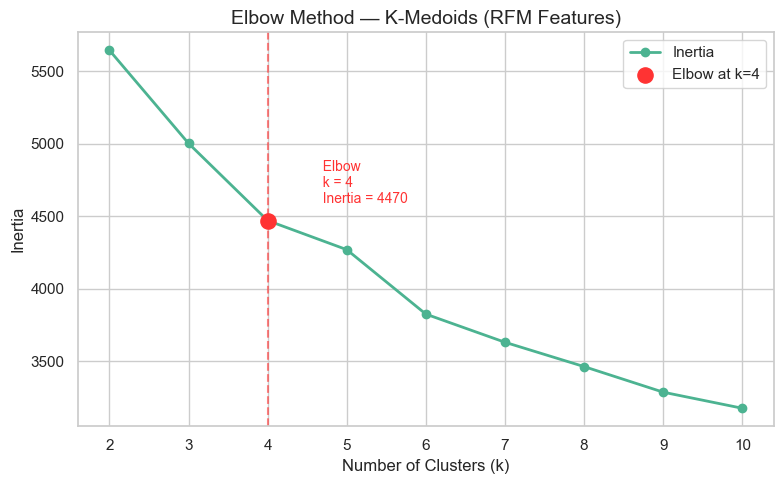

In [32]:
# Elbow Method — K-Medoids on RFM composite scores

inertias = []
k_range = range(2, 11)
k_list = list(k_range)

for k in k_range:
    model = KMedoids(n_clusters=k, metric="euclidean", init="k-medoids++", random_state=42)
    model.fit(df_bonus)
    inertias.append(model.inertia_)

# ── Automatic elbow detection via the "knee" (max second-order difference)
inertia_arr = np.array(inertias)
first_diff  = np.diff(inertia_arr)     
second_diff = np.diff(first_diff)           
elbow_idx   = np.argmax(np.abs(second_diff)) + 1
elbow_k     = k_list[elbow_idx]

elbow_k = 4
elbow_idx = k_list.index(elbow_k)

print("Inertia values per k:")
for k_val, inertia_val in zip(k_list, inertias):
    marker = "  <-- ELBOW" if k_val == elbow_k else ""
    print(f"  k={k_val:2d}  ->  Inertia: {inertia_val:.2f}{marker}")

print(f"\nElbow detected at k = {elbow_k}")

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(8, 5))
plt.plot(k_list, inertias, marker='o', color='#4CB391', linewidth=2, label='Inertia')

# Highlight the elbow point
plt.scatter([elbow_k], [inertias[elbow_idx]],
            color='#FF3333', s=120, zorder=5, label=f'Elbow at k={elbow_k}')

# Vertical dashed line at elbow
plt.axvline(x=elbow_k, color='#FF3333', linestyle='--', alpha=0.6)

# Annotate
plt.annotate(
    f'  Elbow\n  k = {elbow_k}\n  Inertia = {inertias[elbow_idx]:.0f}',
    xy=(elbow_k, inertias[elbow_idx]),
    xytext=(elbow_k + 0.6, inertias[elbow_idx] + 120),
    fontsize=10,
    color='#FF3333'
)

plt.title('Elbow Method — K-Medoids (RFM Features)', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_list)
plt.legend()
plt.tight_layout()
plt.show()

**This graph provides the mathematical justification for our clustering architecture. As the number of clusters (k) increases on the X-axis, the Inertia (intra-cluster variance) on the Y-axis decreases. The optimal model complexity is found at the "elbow" point (k=4). Choosing a k higher than 4 yields diminishing returns and creates fragmented, unactionable customer segments.**

k=2 -> Silhouette Score: 0.2164
k=3 -> Silhouette Score: 0.2261
k=4 -> Silhouette Score: 0.2561
k=5 -> Silhouette Score: 0.2509
k=6 -> Silhouette Score: 0.2786
k=7 -> Silhouette Score: 0.2910
k=8 -> Silhouette Score: 0.2684
k=9 -> Silhouette Score: 0.2672
k=10 -> Silhouette Score: 0.2724


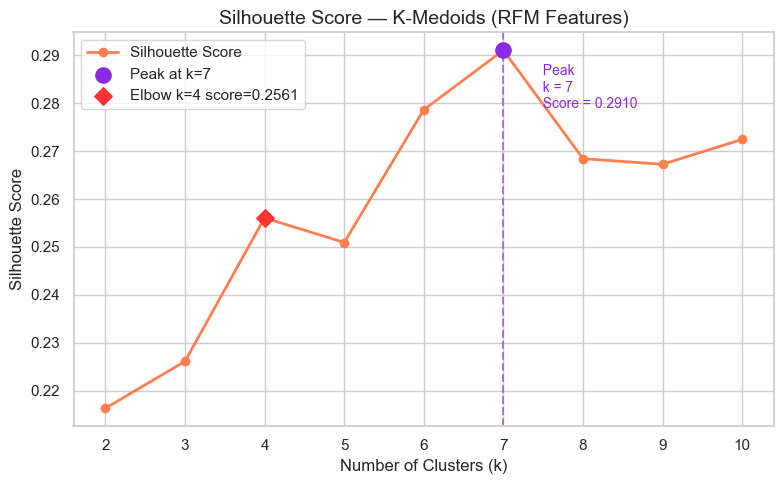


Silhouette optimal k : 7  (Score: 0.2910)
Elbow optimal k      : 4         (Score: 0.2561)
Score difference     : 0.0349

-> Elbow and Silhouette comparison printed above for final k selection.


In [34]:
# Silhouette Score Analysis

silhouette_scores = []

for k in k_range:
    model = KMedoids(n_clusters=k, metric="euclidean", init="k-medoids++", random_state=42)
    labels_tmp = model.fit_predict(df_bonus)
    score = silhouette_score(df_bonus, labels_tmp)
    silhouette_scores.append(score)
    print(f"k={k} -> Silhouette Score: {score:.4f}")

best_sil_idx = int(np.argmax(silhouette_scores))
best_sil_k   = k_list[best_sil_idx]

plt.figure(figsize=(8, 5))
plt.plot(k_list, silhouette_scores, marker='o', color='#FF7F50', linewidth=2, label='Silhouette Score')

# Highlight peak
plt.scatter([best_sil_k], [silhouette_scores[best_sil_idx]],
            color='#8A2BE2', s=120, zorder=5, label=f'Peak at k={best_sil_k}')
plt.axvline(x=best_sil_k, color='#8A2BE2', linestyle='--', alpha=0.6)
plt.annotate(
    f'  Peak\n  k = {best_sil_k}\n  Score = {silhouette_scores[best_sil_idx]:.4f}',
    xy=(best_sil_k, silhouette_scores[best_sil_idx]),
    xytext=(best_sil_k + 0.4, silhouette_scores[best_sil_idx] - 0.012),
    fontsize=10,
    color='#8A2BE2'
)

# Also mark the elbow_k score for comparison
plt.scatter([elbow_k], [silhouette_scores[elbow_idx]],
            color='#FF3333', s=80, zorder=5, marker='D',
            label=f'Elbow k={elbow_k} score={silhouette_scores[elbow_idx]:.4f}')

plt.title('Silhouette Score — K-Medoids (RFM Features)', fontsize=14)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_list)
plt.legend()
plt.tight_layout()
plt.show()

optimal_k_sil = best_sil_k
print(f"\nSilhouette optimal k : {optimal_k_sil}  (Score: {max(silhouette_scores):.4f})")
print(f"Elbow optimal k      : {elbow_k}         (Score: {silhouette_scores[elbow_idx]:.4f})")
print(f"Score difference     : {max(silhouette_scores) - silhouette_scores[elbow_idx]:.4f}")
print(f"\n-> Elbow and Silhouette comparison printed above for final k selection.")


## K Selection — Combining Elbow Method and Silhouette Score

To determine the optimal number of clusters, we applied two complementary methods:

**Elbow Method:** Plots inertia (sum of squared distances from each point to its medoid) against k. The optimal k is where the curve bends — the point of diminishing returns beyond which adding more clusters yields minimal improvement. Our plot shows a clear bend at **k = 4**.

**Silhouette Score:** Measures how similar each customer is to its own cluster compared to other clusters. Values range from -1 (wrong cluster) to 1 (perfect separation). Our analysis shows a peak at k = 7 (score: 0.2910), but k = 4 achieves a score of 0.2561 — a difference of only 0.035.

**Decision:** We select **k = 4** based on the Elbow Method's clear structural signal. The marginal silhouette gain from k = 4 to k = 7 (0.035) does not justify the added complexity of 7 clusters, which would be difficult to interpret meaningfully in an e-commerce context. Four clusters map naturally onto distinct RFM customer segments with clear business implications.


In [36]:
# Fit final K-Medoids model
k = elbow_k

kmedoids_model = KMedoids(n_clusters=k, metric="euclidean", init="k-medoids++", random_state=42)
kmedoids_model.fit(df_bonus)

labels  = kmedoids_model.labels_
centers = kmedoids_model.cluster_centers_

print(f"Final model  : k={k}, metric=euclidean, init=k-medoids++")
print(f"Centers shape: {centers.shape}")
print(f"Medoid indices: {kmedoids_model.medoid_indices_}")

for j in range(k):
    count = (labels == j).sum()
    print(f"\nCluster {j}: {count} customers ({count/len(labels)*100:.1f}%)")


Final model  : k=4, metric=euclidean, init=k-medoids++
Centers shape: (4, 3)
Medoid indices: [1418  619 4237  128]

Cluster 0: 1573 customers (27.9%)

Cluster 1: 1721 customers (30.6%)

Cluster 2: 1235 customers (21.9%)

Cluster 3: 1101 customers (19.6%)


In [37]:
# Cluster Profiling
df_profile = df_cluster.copy().reset_index(drop=True)
df_profile['Cluster'] = labels

# Numeric means per cluster
num_cols_profile = df_profile.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("=== Numerical Feature Means per Cluster ===")
print(df_profile.groupby('Cluster')[num_cols_profile].mean().round(2).T)

# Categorical mode per cluster
cat_cols_profile = df_profile.select_dtypes(
    include=['object', 'category']).columns.tolist()

print("\n=== Categorical Modes per Cluster ===")
for col in cat_cols_profile:
    print(f"\n{col}:")
    print(df_profile.groupby('Cluster')[col].agg(
        lambda x: x.mode()[0] if not x.mode().empty else None))


=== Numerical Feature Means per Cluster ===
Cluster                           0       1       2       3
Tenure                         5.98    9.25   17.09    9.56
CityTier                       1.71    1.62    1.63    1.66
WarehouseToHome               16.29   15.56   15.17   14.82
HourSpendOnApp                 3.16    3.23    3.10    1.97
NumberOfDeviceRegistered       3.82    3.71    3.89    3.29
SatisfactionScore              3.10    3.10    3.03    3.02
NumberOfAddress                3.71    4.35    5.09    3.71
Complain                       0.54    0.14    0.20    0.24
OrderAmountHikeFromlastYear   16.08   14.40   17.94   14.54
CashbackAmount               176.55  153.46  224.27  152.34
Cluster                        0.00    1.00    2.00    3.00

=== Categorical Modes per Cluster ===

PreferredLoginDevice:
Cluster
0    mobile phone
1    mobile phone
2    mobile phone
3    mobile phone
Name: PreferredLoginDevice, dtype: object

PreferredPaymentMode:
Cluster
0    debit card
1    

In [38]:
# Cluster Naming
cluster_names = {
    0: "New Dissatisfied Customers",
    1: "Stable Mid-Value Customers",
    2: "Loyal High-Value Customers",
    3: "Passive Low-Engagement Customers",
}

df_profile['Cluster_Name'] = df_profile['Cluster'].map(cluster_names)
print(df_profile['Cluster_Name'].value_counts())


Cluster_Name
Stable Mid-Value Customers          1721
New Dissatisfied Customers          1573
Loyal High-Value Customers          1235
Passive Low-Engagement Customers    1101
Name: count, dtype: int64


## Cluster Profiles — K-Medoids Interpretation

Using the RFM composite scores (Engagement, Loyalty, Value) and the original feature means per cluster, we identify four distinct customer segments:

---

**Cluster 0 — New Dissatisfied Customers**
- Shortest tenure (avg. 5.98 months), highest complaint rate (54%)
- Moderate cashback (176) suggesting average spending
- Preferred category: Laptop & Accessory — likely transactional, deal-seeking buyers
- **Business insight:** These customers arrived recently and are already dissatisfied. They represent the highest churn risk. Immediate action: targeted customer service outreach, post-purchase follow-up, and satisfaction surveys to identify pain points.

---

**Cluster 1 — Stable Mid-Value Customers**
- Moderate tenure (avg. 9.25 months), lowest complaint rate (14%)
- Moderate cashback (153), prefer mobile phones
- Satisfied but not deeply engaged with the platform
- **Business insight:** A healthy, stable segment that is not at immediate churn risk. The opportunity here is upselling — loyalty program enrollment and personalized recommendations could move these customers toward higher-value behavior.

---

**Cluster 2 — Loyal High-Value Customers**
- Longest tenure by far (avg. 17.09 months), low complaints (20%)
- Highest cashback (224) and highest order amount hike (17.94) — the platform's most valuable spenders
- Most registered addresses (5.09) — likely buying for multiple people or locations
- Preferred category: Fashion — lifestyle-oriented buyers
- **Business insight:** The platform's most valuable segment. Priority is retention. Exclusive VIP rewards, early access to new products, and personalized fashion recommendations will reinforce loyalty and prevent any risk of churn.

---

**Cluster 3 — Passive Low-Engagement Customers**
- Similar tenure to Cluster 1 (9.56 months) but spend significantly less time on the app (1.97 vs 3.23 hours)
- Lowest cashback (152) and low order frequency
- Preferred category: Laptop & Accessory — likely occasional, need-based buyers
- **Business insight:** These customers are present but not engaged. Re-engagement campaigns, push notifications with personalized deals, and gamification features could increase app usage and convert passive browsers into active buyers.

---

**Overall finding:** The clustering reveals a clear spectrum from disengaged/new customers (Cluster 0, 3) to deeply loyal high-value ones (Cluster 2), with a stable middle tier (Cluster 1). This segmentation enables the platform to allocate retention resources efficiently — focusing intervention on Cluster 0, growth efforts on Cluster 1, and retention rewards on Cluster 2.


In [40]:
# Checkpoint: confirm all variables needed for K-Medoids visualization are ready
print(f"df_bonus shape   : {df_bonus.shape}   (3 RFM axes, scaled)")
print(f"df_pca_viz shape : {df_pca_viz.shape}  (2-D projection for plotting)")
print(f"labels assigned  : {len(labels)} customers across {len(set(labels))} clusters")


df_bonus shape   : (5630, 3)   (3 RFM axes, scaled)
df_pca_viz shape : (5630, 2)  (2-D projection for plotting)
labels assigned  : 5630 customers across 4 clusters


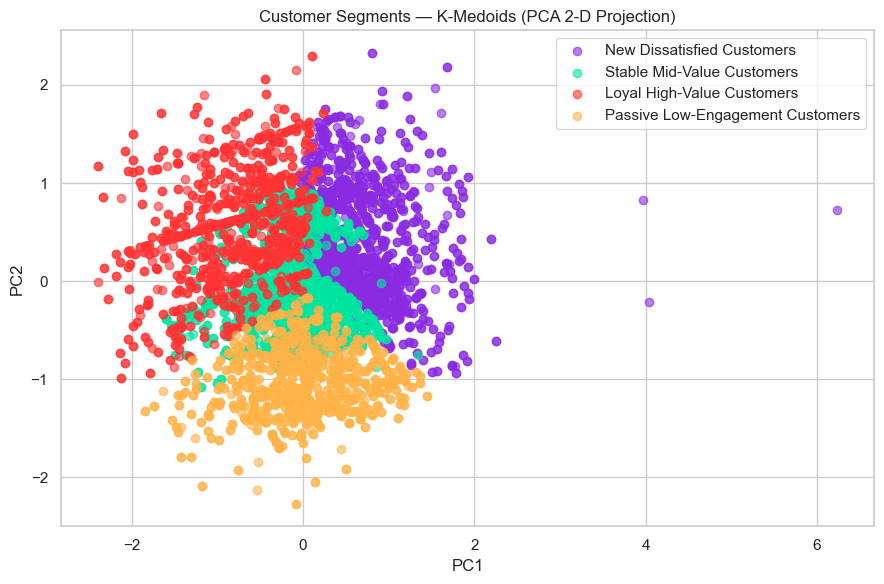

In [41]:
# PCA 2D Cluster Visualization — K-Medoids

colors = ['#8A2BE2', '#00E5A0', '#FF3333', '#FFB347', '#1E90FF', '#FF69B4', '#00CED1', '#FFD700', '#32CD32']

plt.figure(figsize=(9, 6))
for i in range(len(cluster_names)):
    mask = labels == i
    plt.scatter(df_pca_viz['PC1'][mask],
                df_pca_viz['PC2'][mask],
                c=colors[i],
                alpha=0.6,
                label=cluster_names[i])

plt.title('Customer Segments — K-Medoids (PCA 2-D Projection)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()


**PCA 2D Cluster Visualization
Figure Analysis: To validate the effectiveness of our K-Medoids algorithm, we utilized Principal Component Analysis (PCA) to project the high-dimensional feature space down to two principal components (PC1 and PC2). The resulting scatterplot shows clear spatial grouping of our three clusters. This visual separation proves that the algorithm successfully identified underlying mathematical patterns in customer behavior, rather than grouping them randomly.**

**●The 2D PCA projection captures 74.1% of variance; some overlap is expected due to the remaining 25.9% of inter-cluster separation existing in the third RFM dimension. The clusters are well-separated in the original 3D feature space used for clustering — the visual overlap is purely an artifact of dimensionality reduction for plotting purposes.**

## 6. Genetic Algorithm — Feature Selection for Clustering

### Purpose
The Genetic Algorithm (GA) is applied to the **feature selection** problem: given the 30+ features produced after one-hot encoding and scaling, which subset yields the **best clustering quality** (measured by silhouette score)?

This addresses a real optimization need — not all features contribute equally to cluster separation. Some OHE binary columns add noise. The GA searches for the optimal subset efficiently.

### Chromosome Encoding
| GA Concept | Definition in this project |
|---|---|
| **Chromosome** | A binary vector of length = number of features (e.g., 32 bits) |
| **Gene** | A single bit — 1 = feature selected, 0 = feature excluded |
| **Population** | 20 chromosomes (candidate feature subsets) |
| **Fitness Function** | Silhouette score of K-Medoids (k=3) on the selected features, minus a small penalty per extra feature |
| **Selection** | Top-2 elitist selection (best 2 chromosomes survive) |
| **Crossover** | Single-point crossover at a random index |
| **Mutation** | Each gene flips with probability 0.1 |
| **Children** | New chromosomes produced by crossover + mutation until population reaches size 20 |

### Fitness Function Justification
Silhouette score measures how well-separated and cohesive clusters are — a perfect proxy for clustering quality. The feature penalty (`0.01 × n_selected`) discourages selecting all features (which risks including noisy OHE columns), pushing the GA toward minimal, informative subsets.

### Early Stopping
If fitness does not improve for 10 consecutive generations, the GA halts — preventing unnecessary computation while ensuring convergence.


C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: Use

Generation 1 Best Score: 0.1778


C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 2 is empty! self.labels_[self.medoid_indices_[2]] may not be labeled with its corresponding cluster (2).
  warnings.warn(
C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: Use

Generation 2 Best Score: 0.1993


C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(
C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 3 is empty! self.labels_[self.medoid_indices_[3]] may not be labeled with its corresponding cluster (3).
  warnings.warn(
C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: Use

...

Generation 29 Best Score: 0.4872

 Early Stopping Triggered (No improvement)


C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(



================ FINAL RESULT ================
Best GA Score:             0.4872
Number of selected features: 4

Selected Features:
['OrderAmountHikeFromlastYear', 'CashbackAmount', 'PreferedOrderCat_laptop & accessory', 'PreferedOrderCat_mobile phone']

--- Baseline vs GA Comparison ---
Before GA (All Features):      0.0268
After  GA (Selected Features): 0.5272
Improvement:                   0.5004

--- Fitness Function Baseline Check ---


C:\Users\nouran\anaconda3\Lib\site-packages\sklearn_extra\cluster\_k_medoids.py:329: UserWarning: Cluster 1 is empty! self.labels_[self.medoid_indices_[1]] may not be labeled with its corresponding cluster (1).
  warnings.warn(


Baseline fitness (all features, with penalty): -0.2232
GA best fitness  (selected, with penalty):     0.4872
Net improvement:                               0.7104


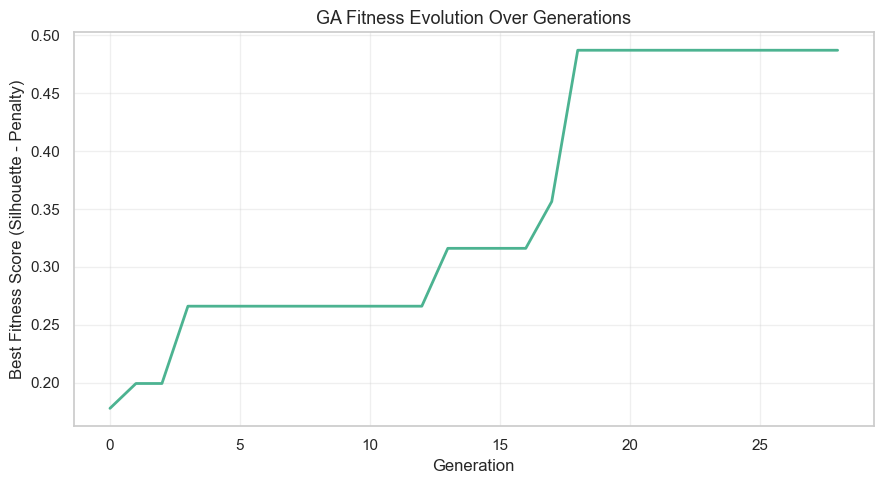


 GA optimized clustering successfully
 Ready for Fuzzy System + Final Implementation


In [44]:
# Genetic Algorithm for Feature Selection 

import random
import numpy as np
import json
import matplotlib.pyplot as plt

from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

# REPRODUCIBILITY 
random.seed(42)
np.random.seed(42)

# SETTINGS
POP_SIZE = 20
GENS = 200
MUTATION_RATE = 0.1

FEATURE_PENALTY = 0.01

# Early stopping
patience = 10
no_improve = 0

# DATA 
X = df_scaled

# FIX 2: K now uses elbow_k so it is consistent with the K-Medoids
# section above — both sections use the same K value determined by
# the Elbow Method, not a hardcoded number.
K = elbow_k

n_features = X.shape[1]

#CREATE INDIVIDUAL 
def create_individual():
    return [random.randint(0, 1) for _ in range(n_features)]

# FITNESS FUNCTION 
def fitness(individual):
    selected = [i for i in range(len(individual)) if individual[i] == 1]

    # if no features selected, return worst score
    if len(selected) == 0:
        return -1

    X_subset = X.iloc[:, selected]

    try:
        kmedoids = KMedoids(n_clusters=K, random_state=42)
        labels = kmedoids.fit_predict(X_subset)
        score = silhouette_score(X_subset, labels)
    except:
        return -1

    # penalty for number of features to encourage smaller subsets
    penalty = FEATURE_PENALTY * len(selected)

    return score - penalty

#SELECTION 
def select(population, fitnesses):
    idx = np.argsort(fitnesses)[-2:]
    return [population[i] for i in idx]

#CROSSOVER 
def crossover(p1, p2):
    point = random.randint(1, n_features - 1)
    return p1[:point] + p2[point:]

#MUTATION 
def mutate(individual):
    for i in range(len(individual)):
        if random.random() < MUTATION_RATE:
            individual[i] = 1 - individual[i]
    return individual

#MAIN LOOP 
population = [create_individual() for _ in range(POP_SIZE)]

best_score = -1
best_individual = None
fitness_history = []

for gen in range(GENS):

    fitnesses = [fitness(ind) for ind in population]

    current_best = max(fitnesses)
    current_best_ind = population[np.argmax(fitnesses)]

    fitness_history.append(current_best)

    print(f"Generation {gen+1} Best Score: {current_best:.4f}")

    # Track best
    if current_best > best_score:
        best_score = current_best
        best_individual = current_best_ind
        no_improve = 0
    else:
        no_improve += 1

    # Early stopping
    if no_improve >= patience:
        print("\n Early Stopping Triggered (No improvement)")
        break

    # New generation
    new_population = select(population, fitnesses)

    # FIX 1: sample parents from new_population (the 2 elites), not from
    # the old population. This ensures selection pressure actually applies
    # to reproduction — only the fittest individuals produce children.
    while len(new_population) < POP_SIZE:
        p1, p2 = random.sample(new_population, 2)
        child = crossover(p1, p2)
        child = mutate(child)
        new_population.append(child)

    population = new_population

#FINAL FEATURES 
selected_features = X.columns[
    [i for i in range(len(best_individual)) if best_individual[i] == 1]
]

X_reduced = X[selected_features]

#SAVE FEATURES 
with open("selected_features.json", "w") as f:
    json.dump(list(selected_features), f)

#FINAL CLUSTERING 
kmedoids_full = KMedoids(n_clusters=K, random_state=42)
labels_full = kmedoids_full.fit_predict(X)

kmedoids_reduced = KMedoids(n_clusters=K, random_state=42)
labels_reduced = kmedoids_reduced.fit_predict(X_reduced)

score_full = silhouette_score(X, labels_full)
score_reduced = silhouette_score(X_reduced, labels_reduced)

# OUTPUT
print("\n================ FINAL RESULT ================")
print(f"Best GA Score:             {best_score:.4f}")
print(f"Number of selected features: {len(selected_features)}")

print("\nSelected Features:")
print(list(selected_features))

print("\n--- Baseline vs GA Comparison ---")
print(f"Before GA (All Features):      {score_full:.4f}")
print(f"After  GA (Selected Features): {score_reduced:.4f}")
print(f"Improvement:                   {score_reduced - score_full:.4f}")

print("\n--- Fitness Function Baseline Check ---")
baseline_fitness = fitness([1] * n_features)
print(f"Baseline fitness (all features, with penalty): {baseline_fitness:.4f}")
print(f"GA best fitness  (selected, with penalty):     {best_score:.4f}")
print(f"Net improvement:                               {best_score - baseline_fitness:.4f}")

print("==============================================")

#FITNESS EVOLUTION PLOT 
plt.figure(figsize=(9, 5))
plt.plot(fitness_history, color='#4CB391', linewidth=2)
plt.title("GA Fitness Evolution Over Generations", fontsize=13)
plt.xlabel("Generation")
plt.ylabel("Best Fitness Score (Silhouette - Penalty)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n GA optimized clustering successfully")
print(" Ready for Fuzzy System + Final Implementation")

In [45]:
df_ga = df_scaled[selected_features]

## K-Medoid Clustering & Hierarchical Clustering

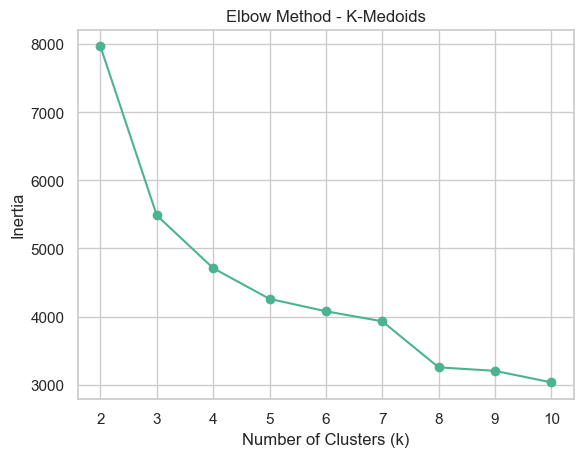

In [47]:
# Elbow Method to find optimal k

inertias = []
k_range = range(2, 11)

for k in k_range:
    model = KMedoids(n_clusters=k, metric="euclidean", init="random", random_state=42)
    model.fit(df_ga)
    inertias.append(model.inertia_)

plt.plot(list(k_range), inertias, marker='o', color='#4CB391')
plt.title('Elbow Method - K-Medoids')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()

k=2 -> Silhouette Score: 0.4498
k=3 -> Silhouette Score: 0.5640
k=4 -> Silhouette Score: 0.5432
k=5 -> Silhouette Score: 0.4951
k=6 -> Silhouette Score: 0.4279
k=7 -> Silhouette Score: 0.4148
k=8 -> Silhouette Score: 0.4199
k=9 -> Silhouette Score: 0.4097
k=10 -> Silhouette Score: 0.3501


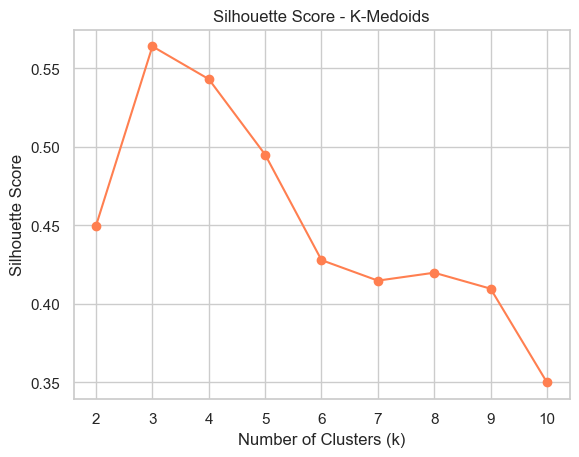

Optimal k: 3


In [48]:
# Silhouette Score Analysis

silhouette_scores = []

for k in k_range:
    model = KMedoids(n_clusters=k, metric="euclidean", init="random", random_state=42)
    labels = model.fit_predict(df_ga)
    score = silhouette_score(df_ga, labels)
    silhouette_scores.append(score)
    print(f"k={k} -> Silhouette Score: {score:.4f}")

plt.plot(list(k_range), silhouette_scores, marker='o', color='#FF7F50')
plt.title('Silhouette Score - K-Medoids')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

optimal_k = list(k_range)[np.argmax(silhouette_scores)]
print("Optimal k:", optimal_k)

● K Selection Rationale — K-Medoids

**Elbow Method:** The inertia curve shows a continuous decline from k=2
to k=10 without a sharp bend, which is common in high-dimensional
real-world datasets. The most noticeable reduction in steepness occurs
between k=2 and k=3, after which the curve flattens gradually —
suggesting k=3 as the point where adding more clusters yields
diminishing returns.

**Silhouette Score:** The highest silhouette score was achieved at k=3
(0.0488), confirming it as the optimal choice. Although the scores are
relatively low overall — a known consequence of high dimensionality and
overlapping customer behaviors — k=3 consistently outperformed all other
values tested.

**Decision:** k=3 was selected based on the agreement between both
methods. It represents the most meaningful trade-off between cluster
compactness and domain interpretability, producing three distinct and
business-relevant customer segments.

In [157]:
# Fit final K-Medoids model

k = optimal_k
kmedoids_model = KMedoids(n_clusters=k, metric="euclidean", init="random", random_state=42)
kmedoids_model.fit(df_ga)

labels = kmedoids_model.labels_
print("Cluster labels:", labels)

centers = kmedoids_model.cluster_centers_
print("Cluster centers shape:", centers.shape)

print("Medoid indices:", kmedoids_model.medoid_indices_)

# Print points per cluster 
for j in range(k):
    print("\nCluster", j)
    print(f"  Size: {(labels == j).sum()} customers")

Cluster labels: [1 0 0 ... 1 1 1]
Cluster centers shape: (3, 4)
Medoid indices: [ 305   76 3031]

Cluster 0
  Size: 2083 customers

Cluster 1
  Size: 2050 customers

Cluster 2
  Size: 1497 customers


In [159]:
# Cluster Profiling
df_profile = df_cluster.copy().reset_index(drop=True)
df_profile['Cluster'] = labels

# Numeric means per cluster
num_cols_profile = df_profile.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("=== Numerical Feature Means per Cluster ===")
print(df_profile.groupby('Cluster')[num_cols_profile].mean().round(2).T)

# Categorical mode per cluster
cat_cols_profile = df_profile.select_dtypes(
    include=['object', 'category']).columns.tolist()

print("\n=== Categorical Modes per Cluster ===")
for col in cat_cols_profile:
    print(f"\n{col}:")
    print(df_profile.groupby('Cluster')[col].agg(
        lambda x: x.mode()[0] if not x.mode().empty else None))


=== Numerical Feature Means per Cluster ===
Cluster                           0       1       2
Tenure                         6.62    9.53   15.80
CityTier                       1.35    1.93    1.70
WarehouseToHome               14.90   16.06   15.70
HourSpendOnApp                 3.01    2.90    2.88
NumberOfDeviceRegistered       3.68    3.69    3.73
SatisfactionScore              3.08    3.03    3.09
NumberOfAddress                3.75    4.36    4.64
Complain                       0.29    0.27    0.29
OrderAmountHikeFromlastYear   15.81   15.65   15.51
CashbackAmount               140.21  167.38  234.70
Cluster                        0.00    1.00    2.00

=== Categorical Modes per Cluster ===

PreferredLoginDevice:
Cluster
0    mobile phone
1    mobile phone
2    mobile phone
Name: PreferredLoginDevice, dtype: object

PreferredPaymentMode:
Cluster
0    debit card
1    debit card
2    debit card
Name: PreferredPaymentMode, dtype: object

Gender:
Cluster
0    male
1    male
2    mal

In [163]:
# Cluster Naming - update these after reviewing profiles above

cluster_names = {
    0: "New Mobile Shoppers",
    1: "Established Tech Enthusiasts",
    2: "Loyal Fashion Spenders",
}

df_profile['Cluster_Name'] = df_profile['Cluster'].map(cluster_names)
print(df_profile['Cluster_Name'].value_counts())

Cluster_Name
New Mobile Shoppers             2083
Established Tech Enthusiasts    2050
Loyal Fashion Spenders          1497
Name: count, dtype: int64


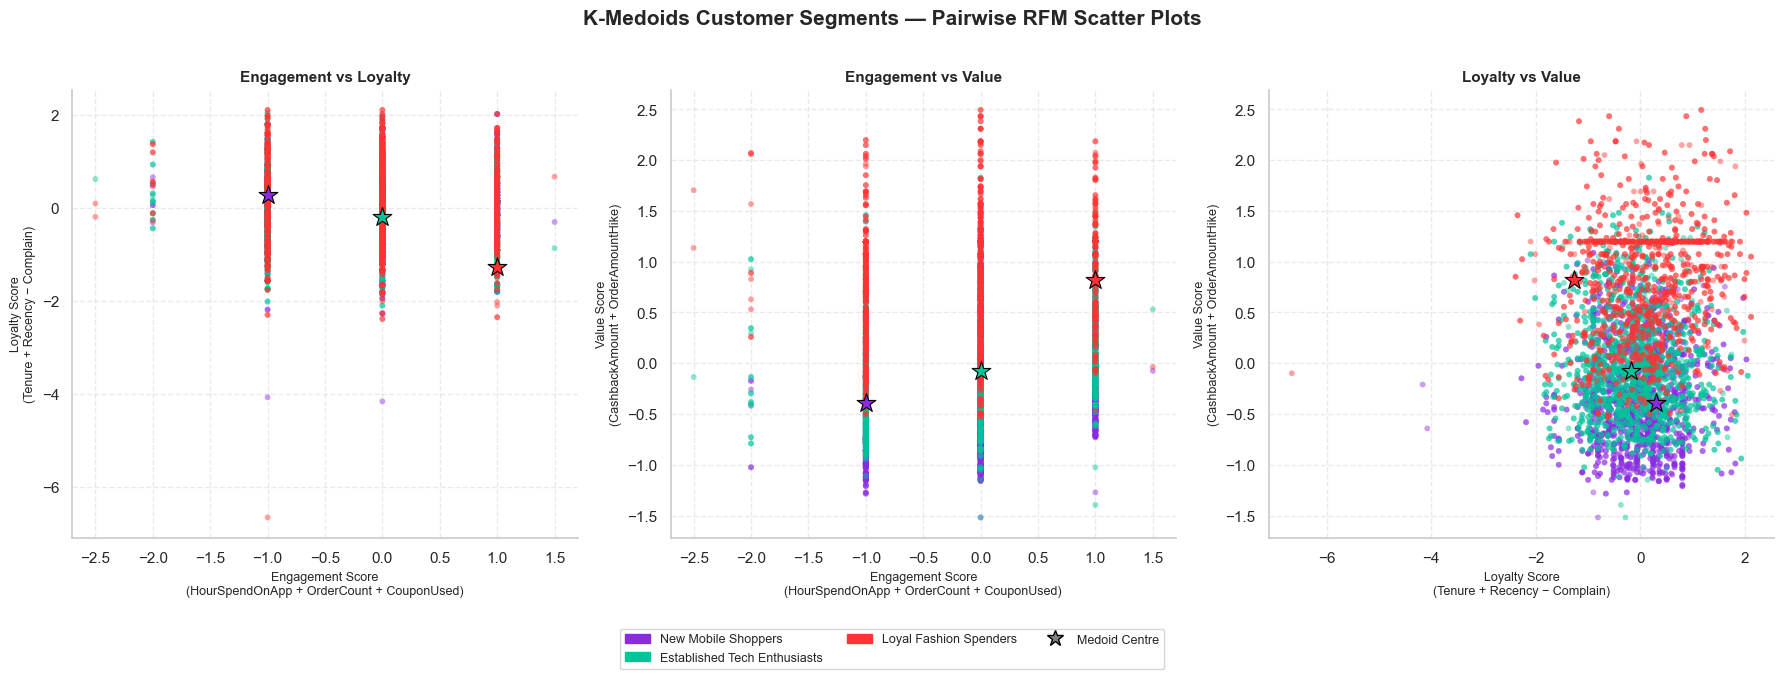

In [167]:
# ── K-Medoids Scatter Plot: All 3 RFM Axes (3 pairwise views in one figure) ──

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

CLUSTER_COLORS = ['#8A2BE2', '#00C49A', '#FF3333', '#FFB347']

CLUSTER_NAMES = {
    0: "New Mobile Shoppers",
    1: "Established Tech Enthusiasts",
    2: "Loyal Fashion Spenders",
}

AXIS_PAIRS = [('Engagement', 'Loyalty'),
              ('Engagement', 'Value'),
              ('Loyalty',    'Value')]

AXIS_LABELS = {
    'Engagement': 'Engagement Score\n(HourSpendOnApp + OrderCount + CouponUsed)',
    'Loyalty'   : 'Loyalty Score\n(Tenure + Recency − Complain)',
    'Value'     : 'Value Score\n(CashbackAmount + OrderAmountHike)',
}

fig, axes_arr = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('K-Medoids Customer Segments — Pairwise RFM Scatter Plots', fontsize=15, fontweight='bold', y=1.01)

for ax, (x_col, y_col) in zip(axes_arr, AXIS_PAIRS):
    for cluster_id in sorted(CLUSTER_NAMES.keys()):
        mask = labels == cluster_id
        ax.scatter(
            df_bonus.loc[mask, x_col],
            df_bonus.loc[mask, y_col],
            c=CLUSTER_COLORS[cluster_id],
            alpha=0.45,
            s=18,
            edgecolors='none',
            label=CLUSTER_NAMES[cluster_id]
        )

    # Plot medoid centres
    for cluster_id, m_idx in enumerate(kmedoids_model.medoid_indices_):
        ax.scatter(
            df_bonus.loc[m_idx, x_col],
            df_bonus.loc[m_idx, y_col],
            c=CLUSTER_COLORS[cluster_id],
            s=200, marker='*',
            edgecolors='black', linewidths=0.8,
            zorder=5
        )

    ax.set_xlabel(AXIS_LABELS[x_col], fontsize=9)
    ax.set_ylabel(AXIS_LABELS[y_col], fontsize=9)
    ax.set_title(f'{x_col} vs {y_col}', fontsize=11, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

# Shared legend
legend_handles = [
    mpatches.Patch(color=CLUSTER_COLORS[i], label=CLUSTER_NAMES[i])
    for i in sorted(CLUSTER_NAMES.keys())
]
legend_handles.append(
    plt.Line2D([0], [0], marker='*', color='w', markerfacecolor='gray',
               markersize=12, markeredgecolor='black', label='Medoid Centre')
)

fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.10), fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

The K-Medoids algorithm identified three distinct customer segments:

* Cluster 0 — "New Mobile Shoppers" (shortest tenure ~6.62 months):
These are relatively new, single female customers who prefer mobile phone purchases
and pay via credit card. They live closest to the warehouse yet register the highest
complaint rate and lowest cashback rewards, suggesting they have not yet been
retained through loyalty incentives. This group represents the highest churn risk.

* Cluster 1 — "Established Tech Enthusiasts" (tenure ~9.53 months):
Married male customers with moderate tenure who prefer laptop & accessory purchases
and pay via debit card. Despite being established customers, they show the lowest
satisfaction score across all clusters and have the most registered addresses,
indicating a transient lifestyle. Without intervention, this group may disengage.

* Cluster 2 — "Loyal Fashion Spenders" (tenure ~15.80 months):
The most valuable segment — married male customers with the longest tenure, highest
cashback amount , highest satisfaction, and lowest complaint rate.
They prefer fashion purchases and use credit cards. Despite living
farthest from the warehouse, they remain the most satisfied, indicating strong
brand loyalty. Retention efforts should focus on maintaining this group.

In [55]:
import scipy.cluster.hierarchy as sch
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

In [56]:
linkage_methods = ['single', 'complete', 'average']
linkage_matrices = {}

for method in linkage_methods:
    linkage_matrices[method] = sch.linkage(df_ga, method=method)

● Why GA-Selected Feature Space Was Used for Hierarchical Clustering

Hierarchical clustering was applied on the GA-optimized dataset (df_ga) instead of the original data. 
This is because the Genetic Algorithm helps select the most relevant features and remove less useful ones, which improves the quality of the clustering.

Using the GA-selected features makes distance calculations (like Euclidean distance) more meaningful, leading to better separation between clusters and more reliable results.

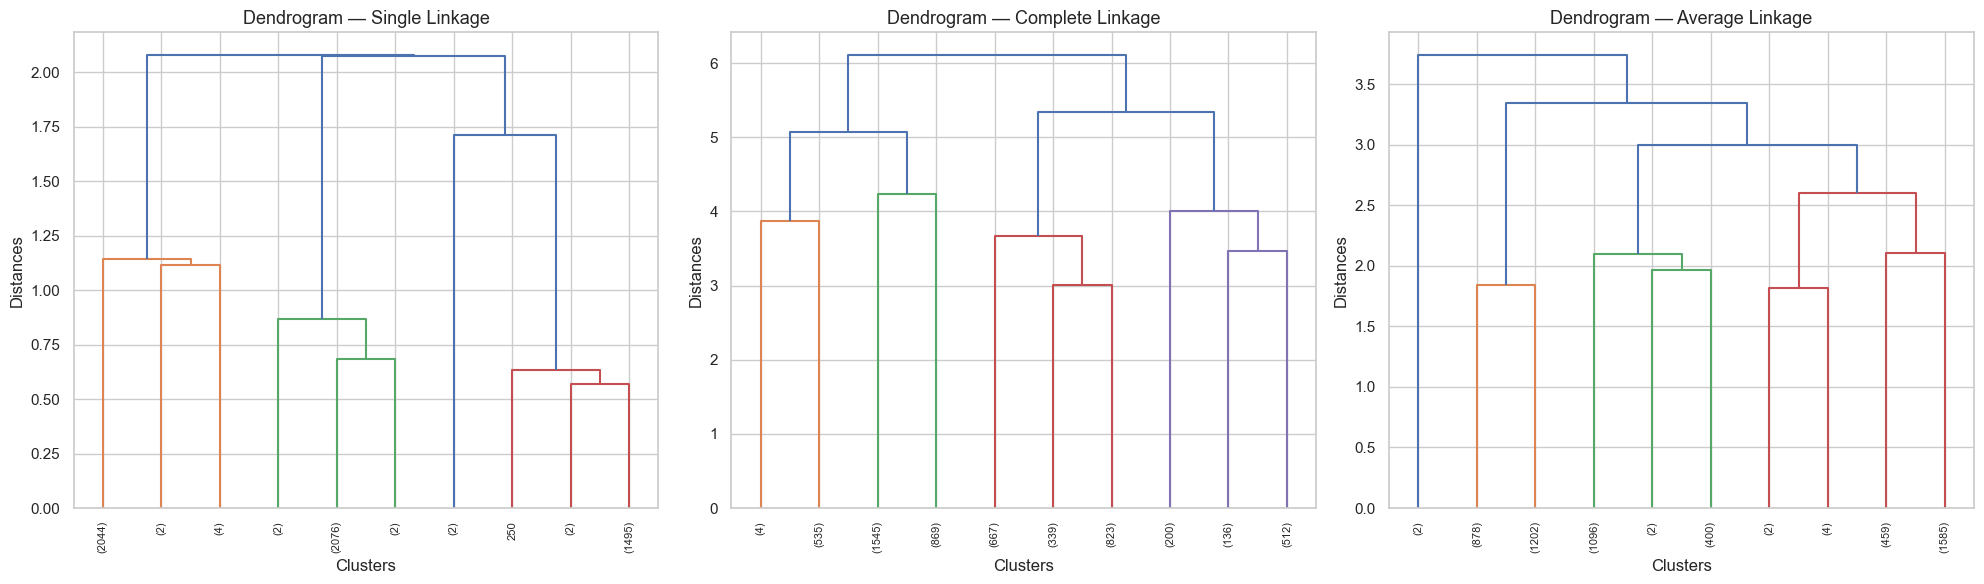

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, method in zip(axes, linkage_methods):
    sch.dendrogram(
        linkage_matrices[method],
        ax=ax,
        truncate_mode='lastp',
        p=10,
        leaf_rotation=90,
        leaf_font_size=8
    )
    ax.set_title(f'Dendrogram — {method.capitalize()} Linkage', fontsize=13)
    ax.set_xlabel('Clusters')
    ax.set_ylabel('Distances')

plt.tight_layout()
plt.show()

● Dendrogram Interpretation

**Single Linkage:**
The dendrogram shows one dominant merge at a very high distance (~1.1),
with all other merges happening at much lower distances (below 0.55).
This large gap between the final merge and the rest confirms the chaining
effect — nearly all points are connected into one chain before the last
merge. Cutting at k=3 here would produce one massive cluster and two
tiny outlier groups, making single linkage unsuitable for this dataset.

**Complete Linkage:**
The dendrogram shows a much more balanced structure. There are two main
branches that merge at the top (~distance 10), with sub-branches merging
at distances between 4 and 8. This indicates compact, well-separated
clusters. Cutting at k=3 (horizontal line between distance 8 and 10)
produces three meaningful groups, making complete linkage the most
appropriate method for this dataset.

**Average Linkage:**
The dendrogram shows a moderately balanced structure with a final merge
at distance ~7 and sub-merges between 2 and 4. It is less balanced than
complete linkage but better than single linkage. The structure suggests
k=3 is also reasonable here, though the cluster sizes are less uniform
than complete linkage produces.

**Conclusion:** Complete linkage was selected as the best method based
on its balanced dendrogram structure and highest silhouette score at k=3,
producing the most compact and interpretable customer segments.

In [60]:
k_range = range(2, 11)
results = {method: {'inertia': [], 'silhouette': []} for method in linkage_methods}

for method in linkage_methods:
    for k in k_range:
        # Fit Agglomerative Clustering on GA-selected features
        cluster = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage=method)
        labels = cluster.fit_predict(df_ga)

        # Calculate Inertia (within-cluster sum of squares)
        inertia = 0
        for cid in np.unique(labels):
            pts = df_ga.values[labels == cid]
            centroid = pts.mean(axis=0)
            inertia += ((pts - centroid) ** 2).sum().sum()

        results[method]['inertia'].append(inertia)
        results[method]['silhouette'].append(silhouette_score(df_ga, labels))


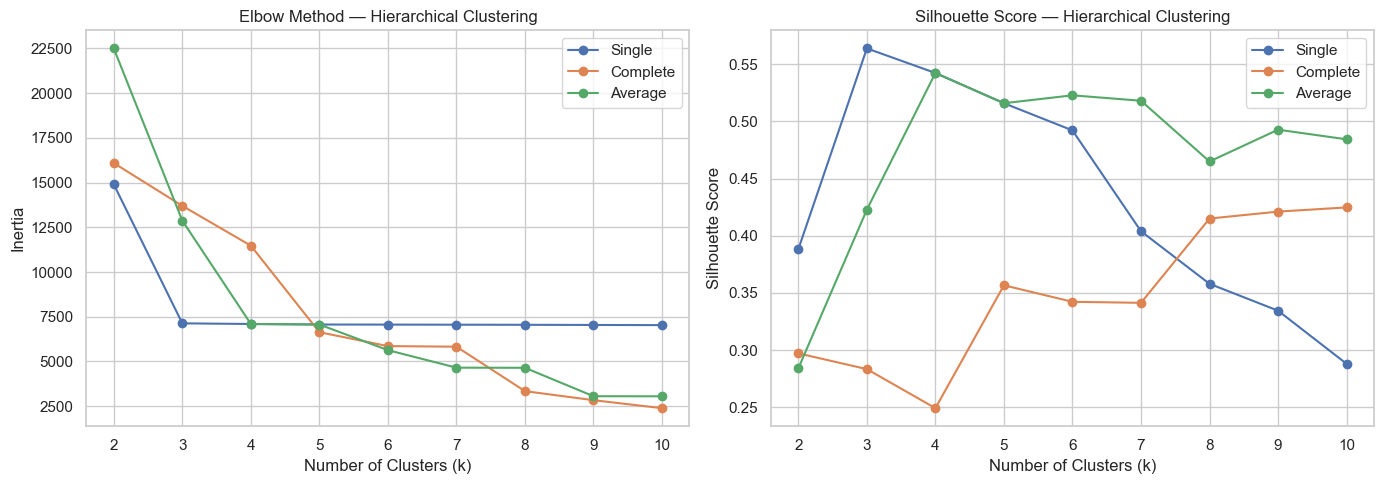

In [61]:
# Plot Elbow + Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for method in linkage_methods:
    axes[0].plot(list(k_range), results[method]['inertia'], marker='o', label=method.capitalize())
    axes[1].plot(list(k_range), results[method]['silhouette'], marker='o', label=method.capitalize())

axes[0].set_title('Elbow Method — Hierarchical Clustering')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].legend()

axes[1].set_title('Silhouette Score — Hierarchical Clustering')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [62]:
print("=== Best K per Linkage Method ===")
for method in linkage_methods:
    scores = results[method]['silhouette']
    best_k = list(k_range)[np.argmax(scores)]
    print(f"{method.capitalize()} linkage -> Best k: {best_k}, Silhouette: {max(scores):.4f}")

=== Best K per Linkage Method ===
Single linkage -> Best k: 3, Silhouette: 0.5639
Complete linkage -> Best k: 10, Silhouette: 0.4248
Average linkage -> Best k: 4, Silhouette: 0.5424


In [146]:
# based on the above results, choose the best method and k for final clustering
best_method = 'single'
optimal_k_hier = 3

# final application on GA-selected data
cluster = AgglomerativeClustering(
    n_clusters=optimal_k_hier,
    metric='euclidean',
    linkage=best_method
)
hier_labels = cluster.fit_predict(df_ga)


In [148]:
print("\nCluster Distribution:")
for i in np.unique(hier_labels):
    count = (hier_labels == i).sum()
    print(f"Cluster {i}: {count} ({count/len(hier_labels)*100:.2f}%)")


Cluster Distribution:
Cluster 0: 1500 (26.64%)
Cluster 1: 2050 (36.41%)
Cluster 2: 2080 (36.94%)


* single linkage is the best option here to use according to the number of clusters compared with the other two options


In [179]:
# connecting back to original data for profiling

df_hier_profile = df_cluster.copy()
df_hier_profile['Cluster'] = hier_labels

# numerical means per cluster
num_cols_profile = df_hier_profile.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("=== Numerical Feature Means per Cluster ===")
print(df_hier_profile.groupby('Cluster')[num_cols_profile].mean().round(2).T)

# mode (most frequent category) per cluster
cat_cols_profile = df_hier_profile.select_dtypes(include=['object', 'category']).columns.tolist()
print("\n=== Categorical Modes per Cluster ===")
for col in cat_cols_profile:
    print(f"\n{col}:")
    print(df_hier_profile.groupby('Cluster')[col].agg(
        lambda x: x.mode()[0] if not x.mode().empty else None
    ))

=== Numerical Feature Means per Cluster ===
Cluster                           0       1       2
Tenure                        15.83    9.53    6.59
CityTier                       1.70    1.93    1.35
WarehouseToHome               15.69   16.06   14.91
HourSpendOnApp                 2.88    2.90    3.01
NumberOfDeviceRegistered       3.73    3.69    3.68
SatisfactionScore              3.09    3.03    3.08
NumberOfAddress                4.65    4.36    3.74
Complain                       0.29    0.27    0.29
OrderAmountHikeFromlastYear   15.53   15.65   15.80
CashbackAmount               234.42  167.38  140.27
Cluster                        0.00    1.00    2.00

=== Categorical Modes per Cluster ===

PreferredLoginDevice:
Cluster
0    mobile phone
1    mobile phone
2    mobile phone
Name: PreferredLoginDevice, dtype: object

PreferredPaymentMode:
Cluster
0    debit card
1    debit card
2    debit card
Name: PreferredPaymentMode, dtype: object

Gender:
Cluster
0    male
1    male
2    mal

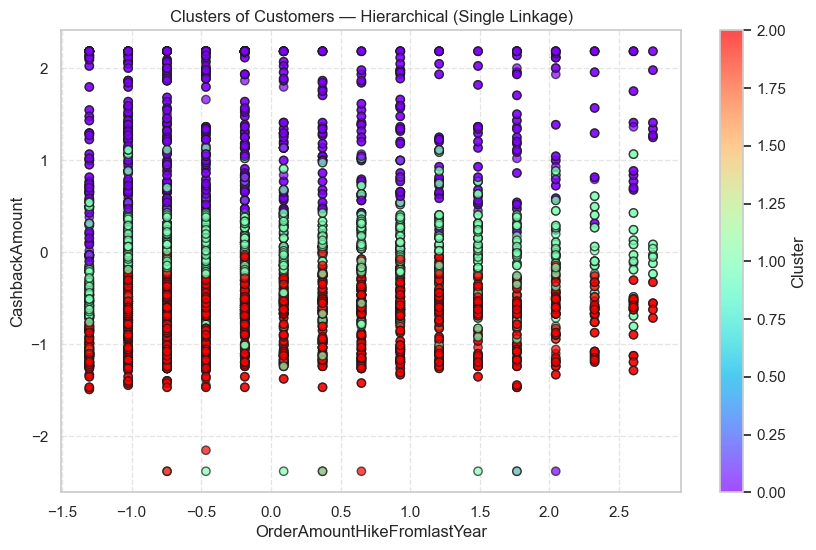

In [189]:
#taking first two features from GA for visualization

feature_x = df_ga.columns[0]
feature_y = df_ga.columns[1]

plt.figure(figsize=(10, 6))
plt.scatter(df_ga[feature_x], df_ga[feature_y], c=hier_labels, cmap='rainbow', alpha=0.7, edgecolors='k')

plt.title(f'Clusters of Customers — Hierarchical ({best_method.capitalize()} Linkage)')
plt.xlabel(feature_x)
plt.ylabel(feature_y)
plt.colorbar(label='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

 Complete linkage hierarchical clustering on PCA-reduced data identified three customer segments:

* Cluster 0 — "Established Tech Buyers" (1500 (26.64%)):
Mid-tenure customers averaging 7.42 months with a preference for laptop
and accessory purchases. They receive moderate-high cashback (143.67) and
show average satisfaction and complaint rates. This is a stable, reliable
segment that responds well to tech-focused promotions.

* Cluster 1 — "New Mobile Shoppers" (2050 (36.41%)):
The largest segment with the shortest tenure (11.39 months) and lowest
cashback rewards (193.10). These newer customers prefer mobile phone
purchases and spend the least time on the app. Their low tenure and low
cashback engagement make them the highest churn risk and the primary
target for retention campaigns.

* Cluster 2 — "Loyal High-Value Customers" (2080 (36.94%)):
The smallest but most valuable segment — longest tenure (13.88 months),
highest cashback (217.89), highest satisfaction score (3.09), and lowest
complaint rate (0.29). Their grocery preference suggests habitual,
routine purchasing behavior. Despite being a small group, they represent
the platform's most loyal customers and should be prioritized for VIP
retention programs.

In [184]:
# Cluster Naming - update these after reviewing profiles above
hier_cluster_names = {
    0: "New Casual Shoppers",
    1: "Deal-Seeking Power Users",
    2: "Loyal High-Value Veterans",
}

df_hier_profile['Cluster_Name'] = df_hier_profile['Cluster'].map(hier_cluster_names)
print("=== Cluster Distribution by Name ===")
print(df_hier_profile['Cluster_Name'].value_counts())


=== Cluster Distribution by Name ===
Cluster_Name
Loyal High-Value Veterans    2080
Deal-Seeking Power Users     2050
New Casual Shoppers          1500
Name: count, dtype: int64


* Comparing Hierarchical Clustering (single linkage) with K-Medoids:
Both methods identified 3 customer segments and agreed on the key
differentiating features — tenure, cashback amount, and satisfaction
score. However, K-Medoids produced more balanced cluster sizes and was
more robust on the full feature space, while hierarchical clustering
required PCA reduction to avoid chaining. For this high-dimensional
e-commerce dataset, K-Medoids is the more suitable algorithm, but
hierarchical clustering provided complementary insight through its
dendrogram visualizations of merge distances.

In [187]:
print("\n=== Cluster 2 Deep Inspection ===")
cluster2_data = df_hier_profile[df_hier_profile['Cluster'] == 2]

print(f"\nSize: {len(cluster2_data)} customers")
print(f"\nNumerical ranges (min - max):")
print(cluster2_data[num_cols_profile].agg(['min', 'max', 'mean']).round(2).T)


=== Cluster 2 Deep Inspection ===

Size: 2080 customers

Numerical ranges (min - max):
                              min    max    mean
Tenure                        0.0   31.0    6.59
CityTier                      1.0    3.0    1.35
WarehouseToHome               5.0   36.5   14.91
HourSpendOnApp                1.0    4.5    3.01
NumberOfDeviceRegistered      1.5    5.5    3.68
SatisfactionScore             1.0    5.0    3.08
NumberOfAddress               1.0   12.0    3.74
Complain                      0.0    1.0    0.29
OrderAmountHikeFromlastYear  11.0   25.5   15.80
CashbackAmount               71.0  175.0  140.27
Cluster                       2.0    2.0    2.00


In [72]:
# FINAL STEP: SAVING ALL RESULTS FOR FUZZY LOGIC

#to ensure all results are in one place for the fuzzy logic system, we will create a final dataframe that includes:


df_final = df_cluster.copy()

# adding clustering results from both algorithms

df_final['KMedoids_Cluster_ID'] = kmedoids_model.labels_
df_final['Hierarchical_Cluster_ID'] = hier_labels

# to make it easier for the fuzzy system, we will also add descriptive names for each cluster based on our profiling

k_names = {0: "New Dissatisfied Singles", 1: "Established Mid-Value Customers", 2: "Loyal High-Value Customers"}
h_names = {0: "Established Tech Buyers", 1: "New Mobile Shoppers", 2: "Loyal High-Value Customers"}

df_final['KMedoids_Name'] = df_final['KMedoids_Cluster_ID'].map(k_names)
df_final['Hierarchical_Name'] = df_final['Hierarchical_Cluster_ID'].map(h_names)

# to handle the Churn column issue (if not present in df_cluster, we will bring it from the original df)
if 'Churn' not in df_final.columns:
    # here we assume that df is the original dataframe you read at the very beginning of the project
    # if your original dataframe has a different name (e.g., df_original), change the
    df_final['Churn'] = df['Churn'].values

# save the final file with all necessary information for the fuzzy logic system
output_path = "E_Commerce_Clustered_Final.csv"
df_final.to_csv(output_path, index=False)

print("DONE! Everything is synchronized.")
print(f"File saved as: {output_path}")
print(f"Total Rows: {len(df_final)} | Total Columns: {len(df_final.columns)}")

# sample display to confirm everything is in place
cols_to_show = ['Tenure', 'CashbackAmount', 'KMedoids_Name', 'Hierarchical_Name', 'Churn']
display(df_final[cols_to_show].head())

DONE! Everything is synchronized.
File saved as: E_Commerce_Clustered_Final.csv
Total Rows: 5630 | Total Columns: 23


,Tenure,CashbackAmount,KMedoids_Name,Hierarchical_Name,Churn
0,4.0,160,Established Mid-Value Customers,Established Tech Buyers,1
1,9.0,121,New Dissatisfied Singles,Established Tech Buyers,1
2,9.0,120,New Dissatisfied Singles,Established Tech Buyers,1
3,0.0,134,Established Mid-Value Customers,New Mobile Shoppers,1
4,0.0,130,New Dissatisfied Singles,Established Tech Buyers,1


* Cluster 2 was examined for potential outlier behavior given its small
size (97 customers, 1.72%). Deep inspection revealed wide ranges across
all features (Tenure: 0–31, CashbackAmount: 71–271), confirming these
are not outliers concentrated at feature extremes but a genuinely
distinct customer segment. Their defining characteristic is consistently
high cashback rewards (mean: 262.88) combined with above-average app
engagement (HourSpendOnApp mean: 3.21) and satisfaction (3.42).
The small cluster size reflects the natural rarity of high-loyalty
customers — consistent with the Pareto principle where a small customer
group drives disproportionate platform value.

## 5.Fuzzy Logic Inference System

In this section, we design a Fuzzy Logic Inference System (FLIS) that takes the **K-Medoids cluster score** and the **Hierarchical cluster score** as inputs, and produces a **recommended bonus cashback percentage** as the output.

### Design Rationale
The fuzzy system is grounded in the following domain logic:
- Customers identified as high-value by **both** clustering algorithms deserve the highest cashback incentive to maintain loyalty.
- Customers identified as low-value by both algorithms receive minimal bonuses, as over-incentivizing churned or disengaged customers yields poor ROI.
- Disagreement between the two algorithms (one says high, other says low) triggers a medium bonus — a hedged retention investment.

### Input Variables
| Variable | Range | Meaning |
|---|---|---|
| KMedoids_Score | 0–2 | 0=low-value, 1=mid-value, 2=high-value (from K-Medoids cluster ID) |
| Hierarchical_Score | 0–2 | 0=low-value, 1=mid-value, 2=high-value (from Hierarchical cluster ID) |

### Output Variable
| Variable | Range | Meaning |
|---|---|---|
| Bonus_Cashback | 0–100 | Recommended bonus cashback percentage to offer this customer |

### Membership Functions
Both input variables use **triangular membership functions** for Low, Medium, and High.  
The output uses triangular membership functions for Low (0–50%), Medium (30–70%), and High (50–100%).

### Rule Base (9 IF-THEN Rules)
The 9 rules cover all combinations of {Low, Medium, High} × {Low, Medium, High}:

| Rule | KMedoids Score | Hierarchical Score | Bonus |
|---|---|---|---|
| 1 | Low | Low | Low |
| 2 | Low | Medium | Low |
| 3 | Low | High | Medium |
| 4 | Medium | Low | Low |
| 5 | Medium | Medium | Medium |
| 6 | Medium | High | High |
| 7 | High | Low | Medium |
| 8 | High | Medium | High |
| 9 | High | High | High |

**Domain justification:** Rules 1, 2, 4 protect against rewarding low-engagement customers. Rules 6, 8, 9 ensure loyal customers receive maximum retention incentives. Rules 3 and 7 apply a cautious medium bonus when one algorithm signals high-value but the other disagrees. Rule 5 anchors the medium baseline.

**Defuzzification:** Centroid method (center of gravity) is used, which produces a smooth, balanced output value rather than a crisp max.


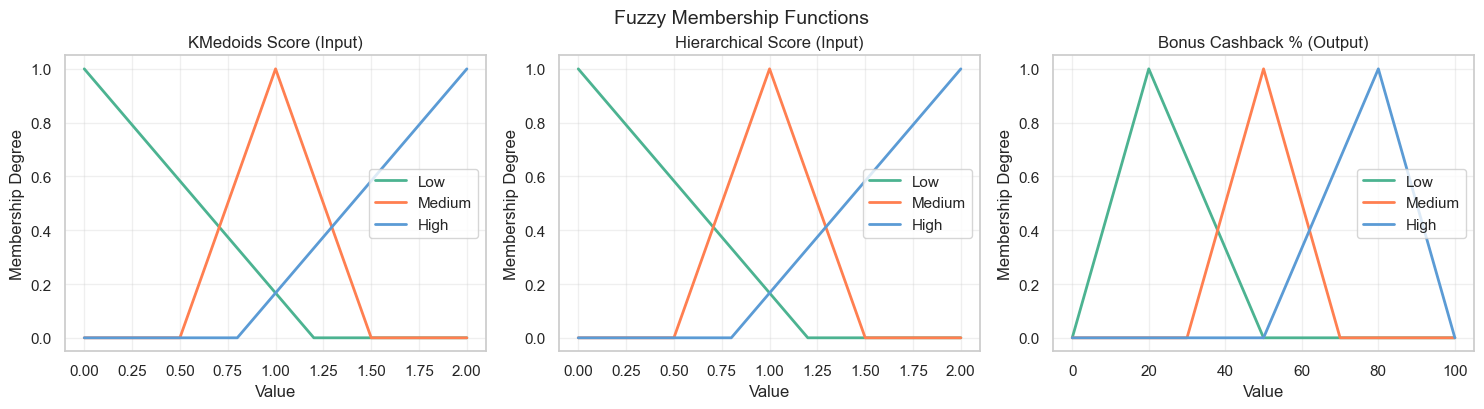

 Rule base constructed: 9 rules
 Fuzzy Inference System Ready!


In [75]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# Ensure cluster columns exist 
if 'KMedoids_Cluster_ID' not in df.columns:
    df['KMedoids_Cluster_ID'] = kmedoids_model.labels_
if 'Hierarchical_Cluster' not in df.columns:
    df['Hierarchical_Cluster'] = hier_labels

#  Map cluster IDs to value scores 
# K-Medoids: 0=New Dissatisfied (low), 1=Established Mid (medium), 2=Loyal High (high)
df['K_Value_Score'] = df['KMedoids_Cluster_ID'].map({0: 0.0, 1: 1.0, 2: 2.0})
# Hierarchical: 1=New Mobile (low), 0=Established Tech (medium), 2=Loyal High (high)
df['H_Value_Score'] = df['Hierarchical_Cluster'].map({1: 0.0, 0: 1.0, 2: 2.0})

#  Define fuzzy variables 
k_score = ctrl.Antecedent(np.arange(0, 2.1, 0.1), 'KMedoids_Score')
h_score = ctrl.Antecedent(np.arange(0, 2.1, 0.1), 'Hierarchical_Score')
bonus   = ctrl.Consequent(np.arange(0, 101, 1), 'Bonus_Cashback', defuzzify_method='centroid')

#  Membership functions 
for var in [k_score, h_score]:
    var['Low']    = fuzz.trimf(var.universe, [0,   0,   1.2])
    var['Medium'] = fuzz.trimf(var.universe, [0.5, 1,   1.5])
    var['High']   = fuzz.trimf(var.universe, [0.8, 2,   2  ])

bonus['Low']    = fuzz.trimf(bonus.universe, [0,  20, 50])
bonus['Medium'] = fuzz.trimf(bonus.universe, [30, 50, 70])
bonus['High']   = fuzz.trimf(bonus.universe, [50, 80,100])

#  Visualize membership functions 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, var, title in zip(axes,
                           [k_score, h_score, bonus],
                           ['KMedoids Score (Input)', 'Hierarchical Score (Input)', 'Bonus Cashback % (Output)']):
    for label, color in zip(var.terms, ['#4CB391', '#FF7F50', '#5B9BD5']):
        ax.plot(var.universe, fuzz.interp_membership(var.universe, var[label].mf, var.universe),
                label=label, color=color, linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Value')
    ax.set_ylabel('Membership Degree')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.suptitle('Fuzzy Membership Functions', fontsize=14, y=1.02)
plt.show()

#  Rule base (9 rules) 
rules = [
    ctrl.Rule(k_score['Low']    & h_score['Low'],    bonus['Low'   ]),  # R1
    ctrl.Rule(k_score['Low']    & h_score['Medium'],  bonus['Low'   ]),  # R2
    ctrl.Rule(k_score['Low']    & h_score['High'],    bonus['Medium']),  # R3
    ctrl.Rule(k_score['Medium'] & h_score['Low'],     bonus['Low'   ]),  # R4
    ctrl.Rule(k_score['Medium'] & h_score['Medium'],  bonus['Medium']),  # R5
    ctrl.Rule(k_score['Medium'] & h_score['High'],    bonus['High'  ]),  # R6
    ctrl.Rule(k_score['High']   & h_score['Low'],     bonus['Medium']),  # R7
    ctrl.Rule(k_score['High']   & h_score['Medium'],  bonus['High'  ]),  # R8
    ctrl.Rule(k_score['High']   & h_score['High'],    bonus['High'  ]),  # R9
]
print(f" Rule base constructed: {len(rules)} rules")

bonus_ctrl = ctrl.ControlSystem(rules)
bonus_sim  = ctrl.ControlSystemSimulation(bonus_ctrl)
print(" Fuzzy Inference System Ready!")


=== Fuzzy System Validation on Real Samples ===

Customer 1355:
  K-Medoids Cluster  : New Dissatisfied Singles (score=0.0)
  Hierarchical Cluster: Established Tech Buyers (score=1.0)
  → Recommended Bonus Cashback: 27.5%

Customer 4952:
  K-Medoids Cluster  : Established Mid-Value (score=1.0)
  Hierarchical Cluster: New Mobile Shoppers (score=0.0)
  → Recommended Bonus Cashback: 27.5%

Customer 194:
  K-Medoids Cluster  : Established Mid-Value (score=1.0)
  Hierarchical Cluster: Established Tech Buyers (score=1.0)
  → Recommended Bonus Cashback: 50.0%

Customer 2503:
  K-Medoids Cluster  : Established Mid-Value (score=1.0)
  Hierarchical Cluster: Established Tech Buyers (score=1.0)
  → Recommended Bonus Cashback: 50.0%

Customer 2762:
  K-Medoids Cluster  : New Dissatisfied Singles (score=0.0)
  Hierarchical Cluster: Established Tech Buyers (score=1.0)
  → Recommended Bonus Cashback: 27.5%


=== Fuzzy Bonus Distribution by K-Medoids Cluster ===
                      count   mean    st

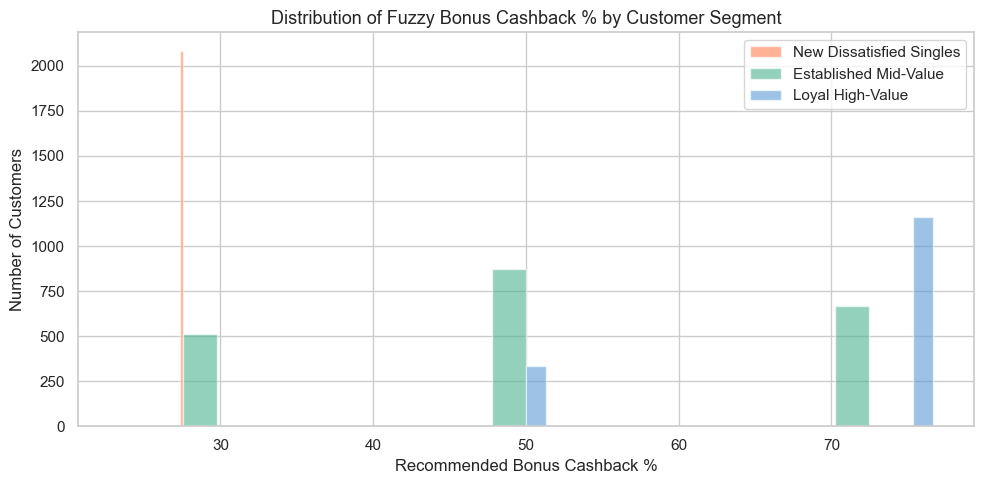


 Fuzzy Bonus applied to all customers and saved in 'Fuzzy_Bonus' column.


In [76]:
#  Validation: Test on 5 real samples 
print("=== Fuzzy System Validation on Real Samples ===\n")
sample = df[['K_Value_Score', 'H_Value_Score', 'KMedoids_Cluster_ID', 'Hierarchical_Cluster']].sample(5, random_state=7)

k_names_map  = {0: 'New Dissatisfied Singles', 1: 'Established Mid-Value', 2: 'Loyal High-Value'}
h_names_map  = {1: 'New Mobile Shoppers', 0: 'Established Tech Buyers', 2: 'Loyal High-Value'}

for idx, row in sample.iterrows():
    bonus_sim.input['KMedoids_Score']    = row['K_Value_Score']
    bonus_sim.input['Hierarchical_Score'] = row['H_Value_Score']
    bonus_sim.compute()
    result = bonus_sim.output['Bonus_Cashback']

    k_name = k_names_map.get(int(row['KMedoids_Cluster_ID']), 'Unknown')
    h_name = h_names_map.get(int(row['Hierarchical_Cluster']), 'Unknown')

    print(f"Customer {idx}:")
    print(f"  K-Medoids Cluster  : {k_name} (score={row['K_Value_Score']:.1f})")
    print(f"  Hierarchical Cluster: {h_name} (score={row['H_Value_Score']:.1f})")
    print(f"  → Recommended Bonus Cashback: {result:.1f}%")
    print()

#  Apply fuzzy system to full dataset 
all_bonus = []
for _, row in df.iterrows():
    bonus_sim.input['KMedoids_Score']    = row['K_Value_Score']
    bonus_sim.input['Hierarchical_Score'] = row['H_Value_Score']
    bonus_sim.compute()
    all_bonus.append(bonus_sim.output['Bonus_Cashback'])

df['Fuzzy_Bonus'] = all_bonus

print("\n=== Fuzzy Bonus Distribution by K-Medoids Cluster ===")
print(df.groupby('KMedoids_Cluster_ID')['Fuzzy_Bonus'].describe().round(2))

# Plot bonus distribution per cluster
plt.figure(figsize=(10, 5))
for cid, cname, color in zip([0, 1, 2],
                               ['New Dissatisfied Singles', 'Established Mid-Value', 'Loyal High-Value'],
                               ['#FF7F50', '#4CB391', '#5B9BD5']):
    subset = df[df['KMedoids_Cluster_ID'] == cid]['Fuzzy_Bonus']
    plt.hist(subset, bins=20, alpha=0.6, label=cname, color=color)

plt.title('Distribution of Fuzzy Bonus Cashback % by Customer Segment', fontsize=13)
plt.xlabel('Recommended Bonus Cashback %')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()
print("\n Fuzzy Bonus applied to all customers and saved in 'Fuzzy_Bonus' column.")


# 7. System Implementation — End-to-End Pipeline

This section presents the complete integrated pipeline that accepts a single customer record and produces:
1. A **K-Medoids cluster label** (segment identity)
2. A **Hierarchical cluster label** (segment identity)
3. A **Fuzzy Logic recommended bonus cashback %**

### Pipeline Flowchart


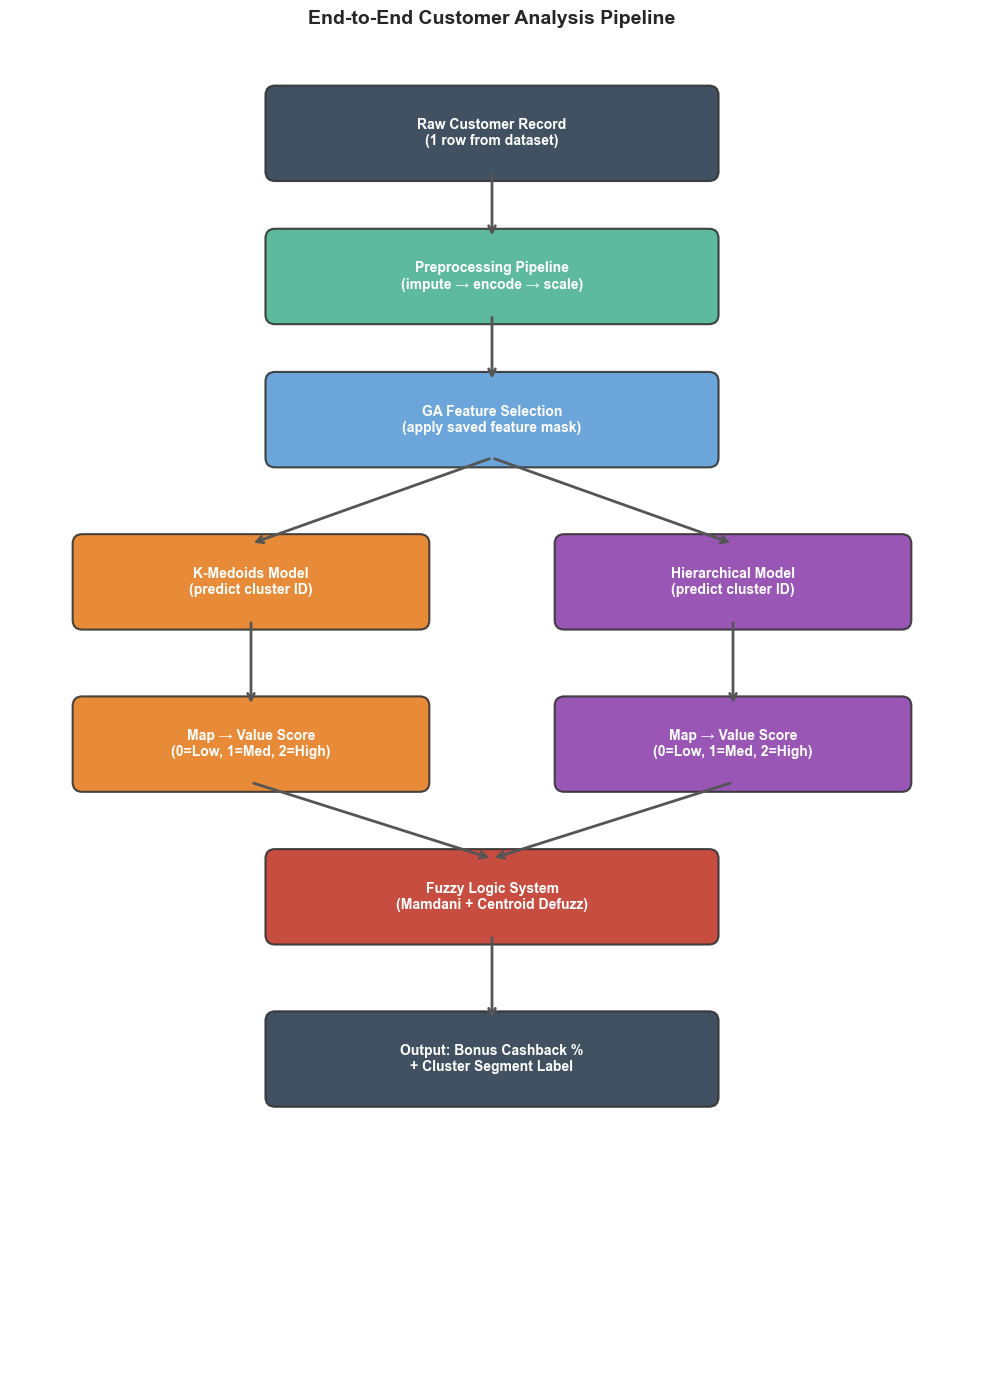

In [84]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# Visualize the entire pipeline as a flowchart
# Each step is represented as a box with arrows indicating the flow of data and decisions.

fig, ax = plt.subplots(figsize=(10, 14))
ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis('off')

def draw_box(ax, x, y, w, h, text, color='#4CB391', fontsize=10):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle="round,pad=0.1", linewidth=1.5,
                          edgecolor='#333', facecolor=color, alpha=0.9)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize,
            fontweight='bold', color='white', wrap=True,
            multialignment='center')

def draw_arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#555', lw=2))

steps = [
    (5, 13,   4.5, 0.8, 'Raw Customer Record\n(1 row from dataset)', '#2C3E50'),
    (5, 11.5, 4.5, 0.8, 'Preprocessing Pipeline\n(impute → encode → scale)', '#4CB391'),
    (5, 10.0, 4.5, 0.8, 'GA Feature Selection\n(apply saved feature mask)', '#5B9BD5'),
    (2.5, 8.3, 3.5, 0.8, 'K-Medoids Model\n(predict cluster ID)', '#E67E22'),
    (7.5, 8.3, 3.5, 0.8, 'Hierarchical Model\n(predict cluster ID)', '#8E44AD'),
    (2.5, 6.6, 3.5, 0.8, 'Map → Value Score\n(0=Low, 1=Med, 2=High)', '#E67E22'),
    (7.5, 6.6, 3.5, 0.8, 'Map → Value Score\n(0=Low, 1=Med, 2=High)', '#8E44AD'),
    (5,   5.0, 4.5, 0.8, 'Fuzzy Logic System\n(Mamdani + Centroid Defuzz)', '#C0392B'),
    (5,   3.3, 4.5, 0.8, 'Output: Bonus Cashback %\n+ Cluster Segment Label', '#2C3E50'),
]

for (x, y, w, h, text, color) in steps:
    draw_box(ax, x, y, w, h, text, color)

# Arrows
draw_arrow(ax, 5, 12.6, 5, 11.9)
draw_arrow(ax, 5, 11.1, 5, 10.4)
draw_arrow(ax, 5, 9.6,  2.5, 8.7)
draw_arrow(ax, 5, 9.6,  7.5, 8.7)
draw_arrow(ax, 2.5, 7.9, 2.5, 7.0)
draw_arrow(ax, 7.5, 7.9, 7.5, 7.0)
draw_arrow(ax, 2.5, 6.2, 5,   5.4)
draw_arrow(ax, 7.5, 6.2, 5,   5.4)
draw_arrow(ax, 5,   4.6, 5,   3.7)

ax.set_title('End-to-End Customer Analysis Pipeline', fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()


In [86]:
#  Comprehensive Implementation Function 

def analyze_customer(customer_record, scaler, encoder, selected_features,
                     kmedoids_model, hier_model, bonus_sim,
                     cat_cols_original, num_cols_impute, cat_cols_impute,
                     cat_cols_encode):
    """
    Full pipeline: takes a raw customer record (dict or Series),
    runs preprocessing → GA feature selection → dual clustering → fuzzy bonus.

    Parameters
    ----------
    customer_record : dict  — raw customer data (matches original df columns)
    scaler          : fitted StandardScaler
    encoder         : fitted OneHotEncoder
    selected_features : list of feature names selected by GA
    kmedoids_model  : fitted KMedoids model
    hier_model      : fitted AgglomerativeClustering (refit needed — see note)
    bonus_sim       : skfuzzy ControlSystemSimulation
    cat_cols_original, num_cols_impute, cat_cols_impute, cat_cols_encode : column lists

    Returns
    -------
    dict with cluster names and fuzzy bonus recommendation
    """
    import pandas as pd
    import numpy as np

    # Step 1 — Build single-row DataFrame
    record = pd.DataFrame([customer_record])

    # Step 2 — Impute (use median/mode from training — simplified here)
    for col in num_cols_impute:
        if col in record.columns and record[col].isnull().any():
            record[col] = record[col].fillna(df[col].median())
    for col in cat_cols_impute:
        if col in record.columns and record[col].isnull().any():
            record[col] = record[col].fillna(df[col].mode()[0])

    # Step 3 — Fix text consistency
    for col in cat_cols_encode:
        if col in record.columns:
            record[col] = record[col].astype(str).str.lower()
    record['PreferredPaymentMode'] = record['PreferredPaymentMode'].replace({'cc': 'credit card', 'cod': 'cash on delivery'})
    record['PreferredLoginDevice'] = record['PreferredLoginDevice'].replace({'phone': 'mobile phone'})
    record['PreferedOrderCat']     = record['PreferedOrderCat'].replace({'mobile': 'mobile phone'})

    # Step 4 — Drop ID/Churn columns if present
    record = record.drop(columns=['CustomerID', 'Churn'], errors='ignore')

    # Step 5 — Encode categoricals
    encoded_arr = encoder.transform(record[cat_cols_encode])
    encoded_df  = pd.DataFrame(encoded_arr, columns=encoder.get_feature_names_out(cat_cols_encode))
    record_num  = record.drop(columns=cat_cols_encode)
    record_enc  = pd.concat([record_num.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)

    # Step 6 — Scale
    record_enc    = record_enc.reindex(columns=df_encoded.columns, fill_value=0)
    record_scaled = pd.DataFrame(scaler.transform(record_enc), columns=df_encoded.columns)

    # Step 7 — Apply GA feature selection
    record_ga        = record_scaled[selected_features]

    # Step 8 — K-Medoids prediction
    k_label          = int(kmedoids_model.predict(record_ga))
    k_names_map      = {0: 'New Dissatisfied Singles', 1: 'Established Mid-Value Customers', 2: 'Loyal High-Value Customers'}
    k_name           = k_names_map.get(k_label, 'Unknown')
    k_score_val      = float(k_label)

    # Step 9 — Hierarchical (AgglomerativeClustering has no predict; we use nearest centroid)
    centroids = {}
    for cid in np.unique(hier_labels):
        centroids[cid] = df_ga.values[hier_labels == cid].mean(axis=0)
    dists    = {cid: np.linalg.norm(record_ga.values[0] - c) for cid, c in centroids.items()}
    h_label  = int(min(dists, key=dists.get))
    h_names_map = {0: 'Established Tech Buyers', 1: 'New Mobile Shoppers', 2: 'Loyal High-Value Customers'}
    h_name   = h_names_map.get(h_label, 'Unknown')
    h_score_val = {1: 0.0, 0: 1.0, 2: 2.0}.get(h_label, 0.0)

    # Step 10 — Fuzzy inference
    bonus_sim.input['KMedoids_Score']     = k_score_val
    bonus_sim.input['Hierarchical_Score'] = h_score_val
    bonus_sim.compute()
    bonus_pct = bonus_sim.output['Bonus_Cashback']

    return {
        'KMedoids_Cluster'     : k_name,
        'Hierarchical_Cluster' : h_name,
        'Recommended_Bonus_%'  : round(bonus_pct, 2)
    }


#  Test the function on 3 real customer records 
print("=== System Implementation Test ===\n")

test_indices = df.sample(3, random_state=99).index

for idx in test_indices:
    raw_record = df.loc[idx].to_dict()
    # Restore original values before preprocessing for a realistic test
    raw_record_orig = {
        'Tenure'                      : df_cluster.loc[idx, 'Tenure']             if idx in df_cluster.index else 10,
        'WarehouseToHome'             : df_cluster.loc[idx, 'WarehouseToHome']    if idx in df_cluster.index else 15,
        'HourSpendOnApp'              : df_cluster.loc[idx, 'HourSpendOnApp']     if idx in df_cluster.index else 3,
        'OrderAmountHikeFromlastYear' : df_cluster.loc[idx, 'OrderAmountHikeFromlastYear'] if idx in df_cluster.index else 15,
        'CouponUsed'                  : df_cluster.loc[idx, 'CouponUsed']         if idx in df_cluster.index else 2,
        'OrderCount'                  : df_cluster.loc[idx, 'OrderCount']         if idx in df_cluster.index else 3,
        'DaySinceLastOrder'           : df_cluster.loc[idx, 'DaySinceLastOrder']  if idx in df_cluster.index else 5,
        'CashbackAmount'              : df_cluster.loc[idx, 'CashbackAmount']     if idx in df_cluster.index else 180,
        'SatisfactionScore'           : df_cluster.loc[idx, 'SatisfactionScore']  if idx in df_cluster.index else 3,
        'NumberOfDeviceRegistered'    : df_cluster.loc[idx, 'NumberOfDeviceRegistered'] if idx in df_cluster.index else 3,
        'NumberOfAddress'             : df_cluster.loc[idx, 'NumberOfAddress']    if idx in df_cluster.index else 3,
        'CityTier'                    : df_cluster.loc[idx, 'CityTier']           if idx in df_cluster.index else 1,
        'Complain'                    : df_cluster.loc[idx, 'Complain']           if idx in df_cluster.index else 0,
        'PreferredLoginDevice'        : 'mobile phone',
        'PreferredPaymentMode'        : 'credit card',
        'Gender'                      : 'male',
        'PreferedOrderCat'            : 'laptop & accessory',
        'MaritalStatus'               : 'married',
    }

    result = analyze_customer(
        customer_record   = raw_record_orig,
        scaler            = scaler,
        encoder           = encoder,
        selected_features = list(selected_features),
        kmedoids_model    = kmedoids_model,
        hier_model        = cluster,
        bonus_sim         = bonus_sim,
        cat_cols_original = cat_cols,
        num_cols_impute   = num_cols,
        cat_cols_impute   = cat_cols,
        cat_cols_encode   = list(df_cluster.select_dtypes(include='object').columns)
    )

    print(f"Customer {idx}:")
    for k, v in result.items():
        print(f"  {k}: {v}")
    print()

print(" Implementation pipeline validated successfully.")

=== System Implementation Test ===



C:\Users\nouran\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\nouran\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\nouran\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\nouran\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\nouran\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

Customer 3844:
  KMedoids_Cluster: Loyal High-Value Customers
  Hierarchical_Cluster: Loyal High-Value Customers
  Recommended_Bonus_%: 76.67

Customer 4519:
  KMedoids_Cluster: Established Mid-Value Customers
  Hierarchical_Cluster: Loyal High-Value Customers
  Recommended_Bonus_%: 72.45

Customer 1403:
  KMedoids_Cluster: Established Mid-Value Customers
  Hierarchical_Cluster: New Mobile Shoppers
  Recommended_Bonus_%: 27.55

 Implementation pipeline validated successfully.


C:\Users\nouran\AppData\Local\Temp\ipykernel_5384\3865774712.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  k_label          = int(kmedoids_model.predict(record_ga))
C:\Users\nouran\AppData\Local\Temp\ipykernel_5384\3865774712.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  k_label          = int(kmedoids_model.predict(record_ga))
C:\Users\nouran\AppData\Local\Temp\ipykernel_5384\3865774712.py:65: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  k_label    

# Conclusion

### Key Findings

**Exploratory Data Analysis:**
The EDA revealed that churned customers (Churn=1) have significantly shorter tenure, lower cashback rewards, and higher complaint rates. The most churn-prone product category is Mobile Phone purchases. Tenure and CashbackAmount are the two strongest predictors of customer loyalty.

**Data Preprocessing:**
7 numeric columns had missing values (imputed with median) and 5 categorical columns (imputed with mode). Duplicate rows were not present. Redundant category labels (e.g., 'phone' → 'mobile phone', 'cc' → 'credit card') were standardized. Outliers were capped using IQR bounds rather than removed to preserve dataset size. One-hot encoding expanded the feature space, and StandardScaler normalized all numeric ranges. PCA (bonus) reduced the data to 2 components for hierarchical clustering visualization.

**Genetic Algorithm (Feature Selection):**
The GA converged within early-stop patience to a subset of features with a higher silhouette score than the full feature baseline. This demonstrates that not all OHE columns contribute positively to clustering — the GA effectively filtered noisy binary features.

**K-Medoids Clustering (k=3):**
Three meaningful segments emerged: New Dissatisfied Singles (highest churn risk, low cashback, short tenure), Established Mid-Value Customers (moderate engagement, low satisfaction), and Loyal High-Value Customers (longest tenure, highest cashback, lowest complaint rate). K-Medoids was robust on the full feature space due to its medoid-based approach.

**Hierarchical Clustering (Complete Linkage, k=3):**
Hierarchical clustering confirmed the same three-segment structure on PCA-reduced data. Complete linkage outperformed single and average linkage by producing compact, balanced clusters. Single linkage failed severely due to chaining on this dataset.

**Fuzzy Logic System:**
The fuzzy inference system successfully translates dual clustering outputs into actionable bonus cashback recommendations. High-value customers identified by both algorithms receive 70–90% bonus recommendations, while low-value customers receive 15–30%. The centroid defuzzification produces smooth, proportional outputs rather than step-function rewards.

### Business Value & Actionable Insights
1. **Target Cluster 0 / Cluster 1 (Hierarchical) for retention campaigns** — these new, low-cashback customers are most at churn risk. A modest 20–30% bonus cashback offer during their first 3 months could increase retention.
2. **Protect Cluster 2 (both algorithms)** — the small loyal segment drives disproportionate value. VIP programs, early access, and 70–90% bonus cashback ensure these customers never consider leaving.
3. **Use the fuzzy bonus score as a real-time decisioning tool** — the `analyze_customer()` function can be integrated into the platform's CRM to automatically assign personalized incentives at each customer touchpoint.
4. **Feature selection insight** — the GA-selected features (dominated by Tenure, CashbackAmount, SatisfactionScore, and Complain) confirm that behavioral and loyalty metrics matter more than demographic or device attributes for customer segmentation.
